# Predictive Maintenance: Failure Prediction and Anomaly Detection for Industrial Machines

---

# 1.0 Introduction  
Ce projet explore l'application de l'apprentissage automatique pour la maintenance prédictive dans un contexte industriel. Les objectifs sont les suivants :  
- Prédire les pannes potentielles des machines à l'aide de modèles de classification supervisée (XGBoost, Random Forest)  
- Détecter des anomalies subtiles non visibles avec les systèmes traditionnels en utilisant des modèles non supervisés (Isolation Forest)  

---

## 1.1 Table des matières  
1. Consultation et préparation des données  
2. Analyse exploratoire des données (EDA)  
3. Classification supervisée (prédiction des pannes et identification du type de panne)  
4. Évaluation des modèles et interprétation des résultats  
5. Détection d'anomalies (apprentissage non supervisé)  
6. Insights et visualisation  
7. Recommandations et plan d'action


## 1.2 Installation des bibliothèques

In [1]:
%pip install -q pandas
%pip install -q hvplot
%pip install -q matplotlib
%pip install -q seaborn
%pip install -q numpy
%pip install -q scikit-learn
%pip install -q imbalanced-learn
%pip install -q xgboost
%pip install -q lightgbm

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 1.3 Importation des librairies

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hvplot.pandas
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    classification_report, confusion_matrix, roc_auc_score, make_scorer 
)
from sklearn.model_selection import cross_validate, StratifiedKFold
import warnings
from imblearn.combine import SMOTETomek
# Ignorer les FutureWarnings liés à force_all_finite et sklearn_tags
warnings.filterwarnings("ignore", category=FutureWarning)


# 2.0 Consultations des données

Chargement de l'ensemble de données dans « PDM_data » et vérification du type de données.

In [3]:
# pd.read_csv méthode qui permet de lire et de charger un fichier csv dans une variable
PDM_data = pd.read_csv('predictive_maintenance.csv')

# Contrôle du type de dataframe
type(PDM_data)

pandas.core.frame.DataFrame

**Ensuite, l'information sur le jeu de données est examinée**
- Vérifier que les données sont chargées dans un format utilisable.
- Connaître le nombre de colonnes et le nombre de lignes ainsi que les noms
- Nombre de valeurs manquantes par colonne.


In [4]:
# Avec la méthode .info il est possible d'obtenir des information sur un dataframe
PDM_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


Le jeu de données consiste en 10 000 lignes et 10 colonnes, avec des types de données de colonnes incluant int64, object et float64.

Il n'y a pas de valeurs manquantes dans le jeu de données original.

Cependant, deux caractéristiques potentiellement précieuses pour améliorer la précision du jeu de données pourraient être la différence de température entre la température de l'air et la température du processus, ainsi que la puissance.

# 3.0 Préparation des données


Nous introduisons deux nouvelles colonnes : **Temp_Diff** (différence entre la température du processus et la température de l'air) pour capturer les potentiels déséquilibres thermiques, et **Power** (calculée à partir du couple et de la vitesse de rotation) pour représenter la charge mécanique globale. 
Ces caractéristiques donnent une meilleure idée du stress thermique et mécanique, ce qui peut potentiellement améliorer la précision.

In [5]:
# Ajout d'une nouvelle colonne "Temp_Diff [K]"
PDM_data['Temp_Diff [K]'] = PDM_data['Process temperature [K]'] - PDM_data['Air temperature [K]']

# Convertir la vitesse de rotation de rpm en rad/s et calculer la puissance en watts
# La puissance (W) = Couple (Nm) * Vitesse angulaire (rad/s)

PDM_data['Power [W]'] = (PDM_data['Torque [Nm]'] *(2 * np.pi / 60) * PDM_data['Rotational speed [rpm]']) # Facteur de conversion de rpm en rad/s

Ensuite, nous affichons les 15 premières lignes pour voir à quoi ressemble le jeu de données.

In [6]:
# Affichage des 15 premières lignes du DataFrame
PDM_data.head(15)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Temp_Diff [K],Power [W]
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure,10.5,6951.590560
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure,10.5,6826.722724
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure,10.4,7749.387543
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure,10.4,5927.504659
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure,10.5,5897.816608
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,No Failure,10.5,6252.554779
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,No Failure,10.5,6917.703247
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,No Failure,10.5,6428.264056
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,No Failure,10.4,4992.639989
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,No Failure,10.5,5104.878623


Nous allons calculer les statistiques importantes pour chaque colonne, y compris la moyenne, l'écart-type, le minimum, le maximum et les quartiles. Pour d'améliorer la lisibilité des données, les colonnes non numériques sont exclues des calculs statistiques.

In [7]:
# Suppression des colonnes non numériques et des colonnes qui ne correspondent pas aux capteurs de la machine
PDM_data_drop = PDM_data.drop(columns= ["UDI", "Product ID" , "Type" , "Failure Type", "Target"])

# Avec la méthode .describe, cela permet de visualiser les statistiques importantes
PDM_data_drop.describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temp_Diff [K],Power [W]
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,10.000630,6279.744953
std,2.000259,1.483734,179.284096,9.968934,63.654147,1.001094,1067.418295
min,295.300000,305.700000,1168.000000,3.800000,0.000000,7.600000,1148.440610
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,9.300000,5561.184484
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,9.800000,6271.027344
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,11.000000,7003.002724
max,304.500000,313.800000,2886.000000,76.600000,253.000000,12.100000,10469.923005


- Les données semblent relativement propres et stables.
- Les valeurs aberrantes dans le couple (Torque) et l'usure de l'outil (Tool wear) pourraient constituer des indicateurs précoces de défaillances potentielles.
- les valeurs maximales pour la vitesse de rotation (Rotational speed), le couple (Torque) et l'usure de l'outil (Tool wear) sont nettement supérieures à leurs troisièmes quartiles, suggérant des conditions extrêmes ou des anomalies.

Compter les lignes où 'Target' est égal à 1 et 0 permet de vérifier la répartition des classes dans le jeu de données, ce qui est important pour 
connaître l'équilibre des classes et ajuster les méthodes de modélisation en conséquence.

In [8]:
print(PDM_data['Target'].value_counts())

Target
0    9661
1     339
Name: count, dtype: int64


La répartition des classes montre un déséquilibre important, avec très peu de cas où 'Target' est égal à 1 par rapport à ceux où 'Target' est égal à 0, ce qui va nécessiter des ajustements dans le modèle pour traiter ce déséquilibre.

Nous analysons les différents types de pannes et la quantité présents dans le jeu de données.

In [9]:
print(PDM_data['Failure Type'].value_counts())

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64


Le nombre de pannes est largement dominé par les "No Failure", alors que les autres types de pannes sont beaucoup moins fréquents, avec "Heat Dissipation Failure" étant le plus courant après, suivi de "Power Failure" et "Overstrain Failure".
Cela entraînera un déséquilibre des classes dans le modèle, ce qui pourrait rendre plus difficile la détection des types de pannes moins fréquents, nécessitant également des ajustements dans les techniques de traitement des données.

# 4.0 Analyse exploratoire des données (EDA)

Un histogramme de la distribution du couple (Torque [Nm]) a été généré pour examiner visuellement la distribution des valeurs du couple, d'identifier des valeurs extrêmes ou aberrantes et de repérer des zones où le couple est concentré. Le couple est utilisé car il reflète directement la charge mécanique et la performance de la machine.

In [10]:
# Ce code génère un histogramme de la distribution du couple avec 50 bins, cela permet une granularité suffisante pour capturer les variations des données
PDM_data.hvplot.hist(y="Torque [Nm]", bins=50, title="Distribution du couple [Nm]")

:Histogram   [Torque [Nm]]   (Count)

Le graphique montre comment le couple (Torque [Nm]) est réparti. On voit que la plupart des valeurs se situent autour de 40 Nm, avec un nombre moins important de valeurs très faibles ou très élevées. Cela indique une répartition assez équilibrée, avec un pic autour de cette valeur centrale.

Un histogramme de la distribution de la différence de température (Temp_Diff) est généré pour détecter les tendances, les anomalies et les zones de risque potentiel liées aux variations de température, qui peuvent avoir un impact sur les performances globales et les taux de défaillance des machines.

In [11]:
PDM_data.hvplot.hist(y="Temp_Diff [K]", bins=50, title="Distribution de la différence de température [K]")

:Histogram   [Temp_Diff [K]]   (Count)

Le graphique montre la répartition de la différence de température (Temp_Diff [K]). On remarque plusieurs pics autour des valeurs de 9, 10 et 11 K, ce qui suggère que la différence de température varie principalement dans cette plage, avec moins de valeurs extrêmes en dehors de ces zones. Cela montre une distribution assez concentrée avec quelques variations.

Le graphique « Vitesse vs Couple » est créé pour voir comment la vitesse de rotation et le couple sont liés, ce qui aide à repérer des tendances et une bonne corrélation.

In [12]:
PDM_data.hvplot.scatter(x='Rotational speed [rpm]', y='Torque [Nm]', title="Vitesse vs couple")

:Scatter   [Rotational speed [rpm]]   (Torque [Nm])

On peut voir qu'à mesure que la vitesse de rotation augmente, le couple diminue, ce qui est assez typique, plus la machine tourne vite, moins elle exerce de force. Les points suivent une tendance globale, montrant une décroissance du couple avec la vitesse ce qui est normal.

Le pair plot est utile pour voir comment toutes les variables numériques sont liées, repérer les corrélations, détecter des tendances complexes et trouver des anomalies.

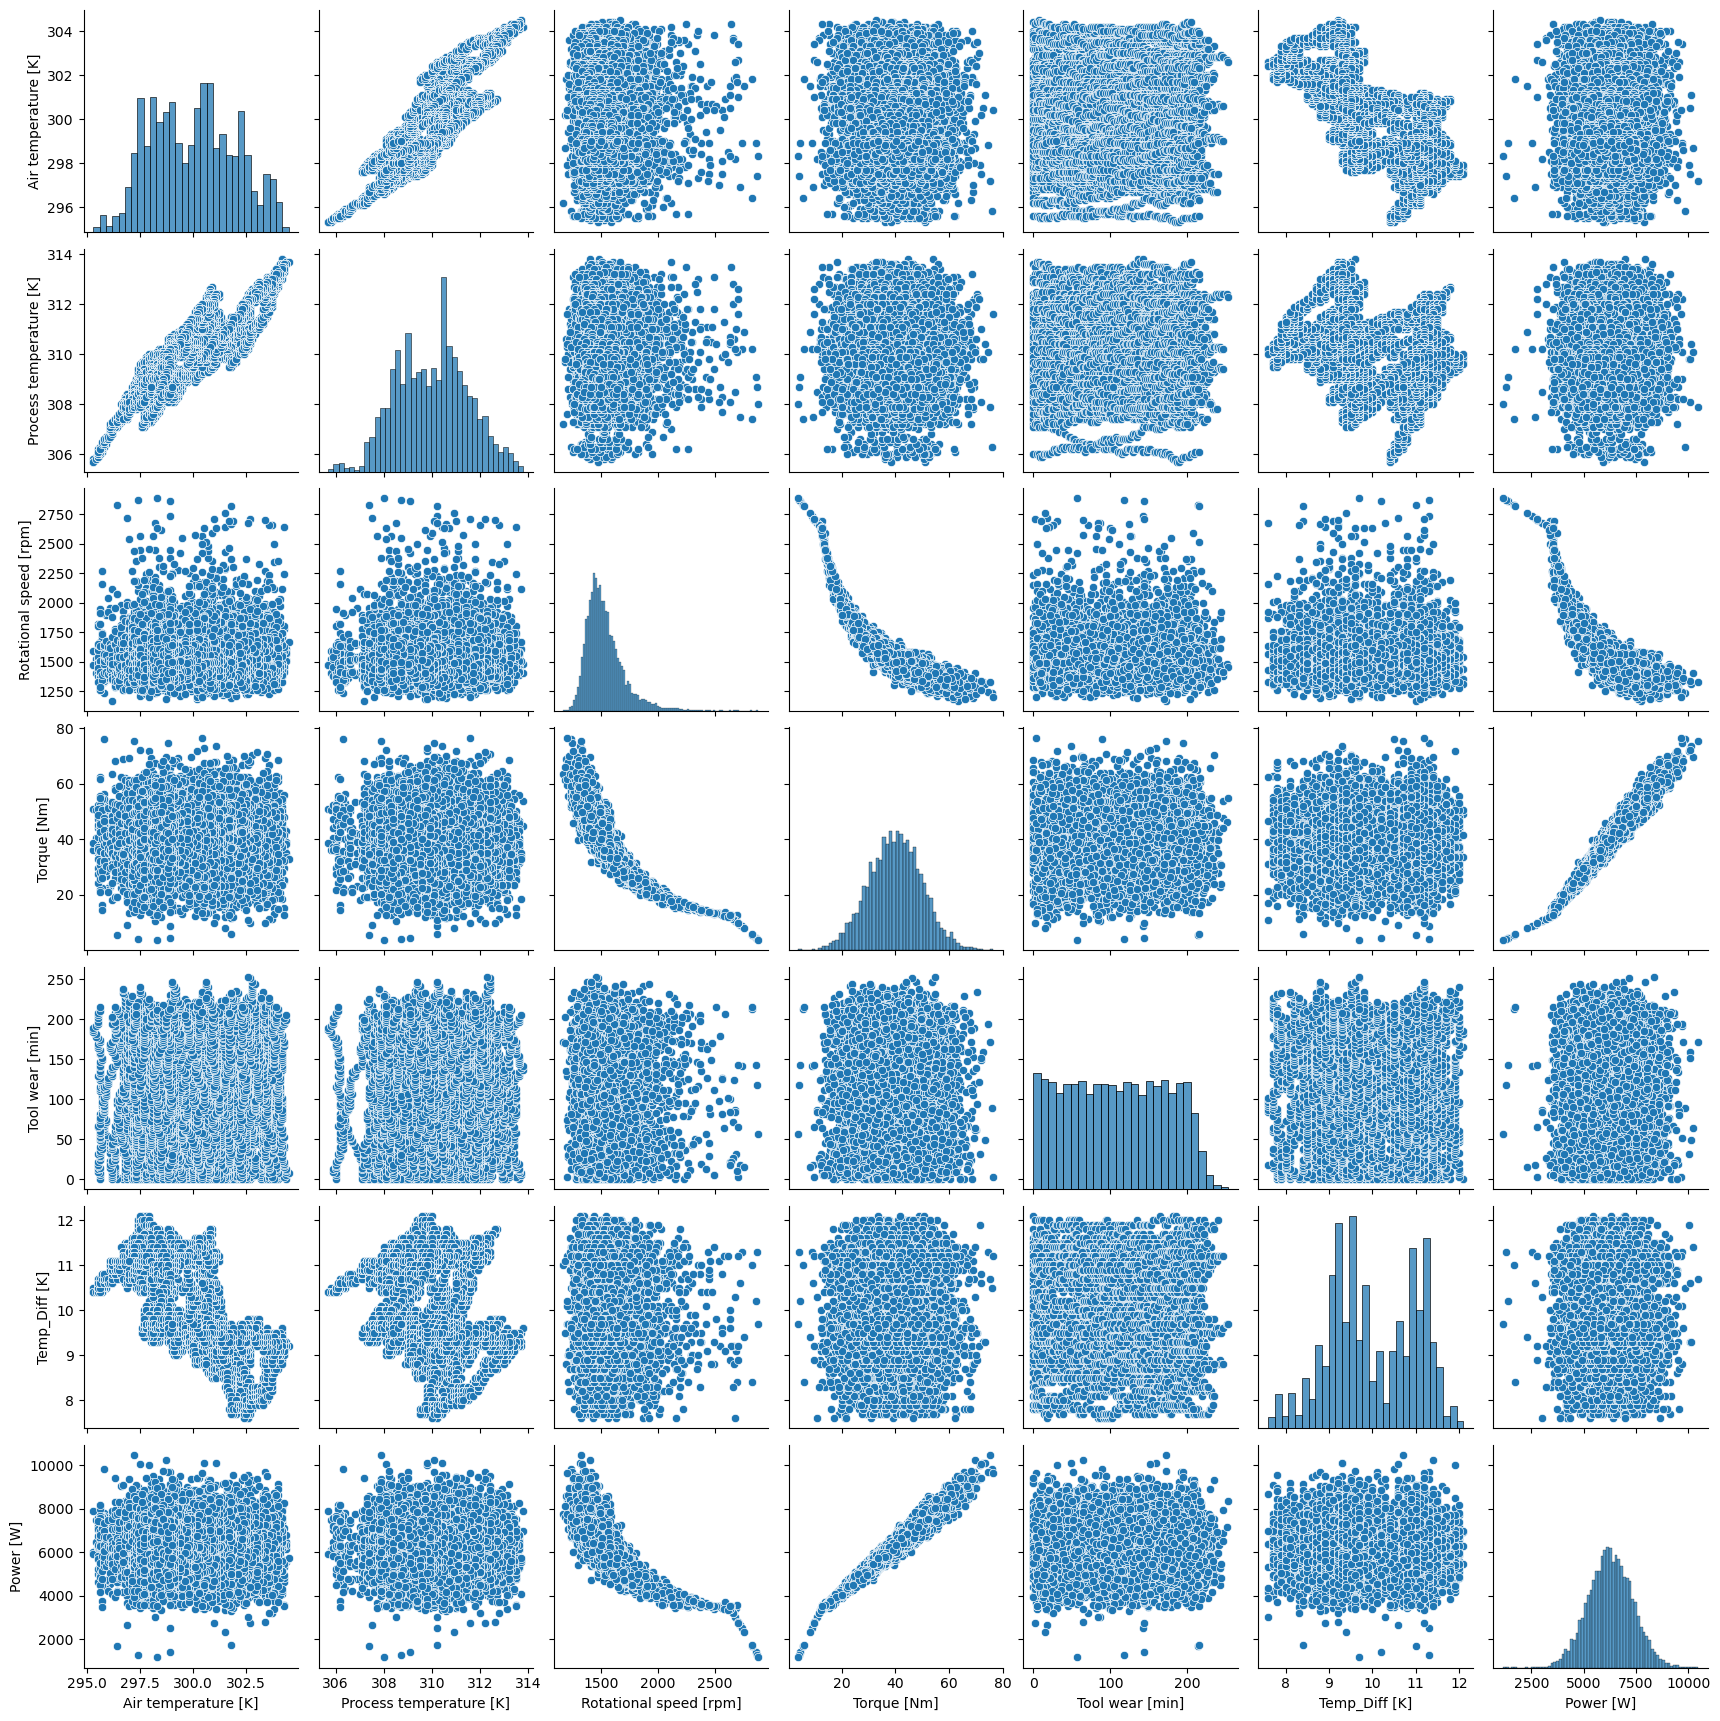

In [13]:
sns_plot = sns.pairplot(PDM_data_drop.select_dtypes(include='number'))

On utilise la heatmap pour voir la force et la direction des relations entre les variables, repérer les corrélations fortes ou faibles.

Text(0.5, 1.0, 'Correlation heatmap')

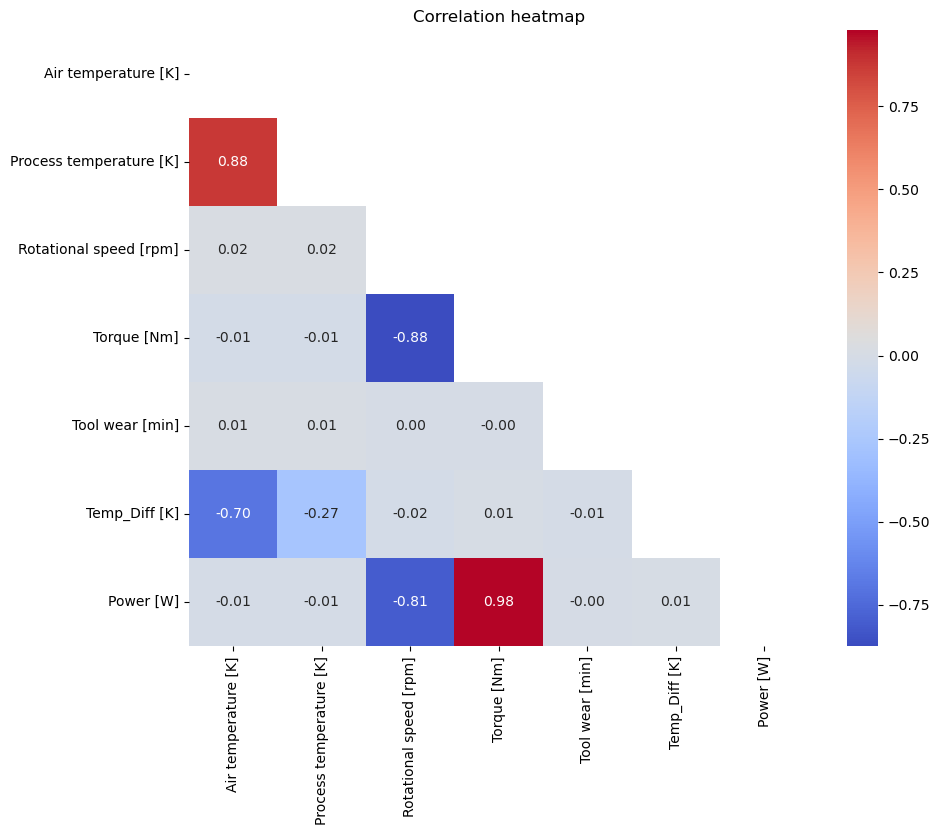

In [14]:
# On enlève les colonnes "Target" et "UDI" et on garde seulement les colonnes numériques
numeric_data = PDM_data.drop(columns=["Target", "UDI"]).select_dtypes(include='number')

# On calcule la matrice de corrélation entre les variables numériques
calc = numeric_data.corr()

# On crée un masque pour ne pas afficher la moitié supérieure de la matrice (pour éviter la redondance)
mask = np.triu(np.ones_like(calc, dtype=bool))

# On crée un graphique pour afficher la heatmap de corrélation
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax, mask=mask)

# Titre du graphique
plt.title("Correlation heatmap")


- **Relations clés :**  
   - Corrélation négative forte entre la vitesse de rotation et le couple (-0,88).  
   - Corrélation négative faible entre la température du processus et la différence de température (-0,27).  
   - Corrélation négative forte entre la température de l'air et la différence de température (-0,70).

- **Points importants :**  
   - À mesure que la température du processus augmente, la vitesse de rotation tend à augmenter.  
   - Il n'y a pas de corrélation entre la température du processus, la vitesse de rotation et le couple.  
   - La différence de température est plus marquée à des températures de l'air plus basses.  
   - Une température de processus plus élevée est liée à une différence de température plus faible.


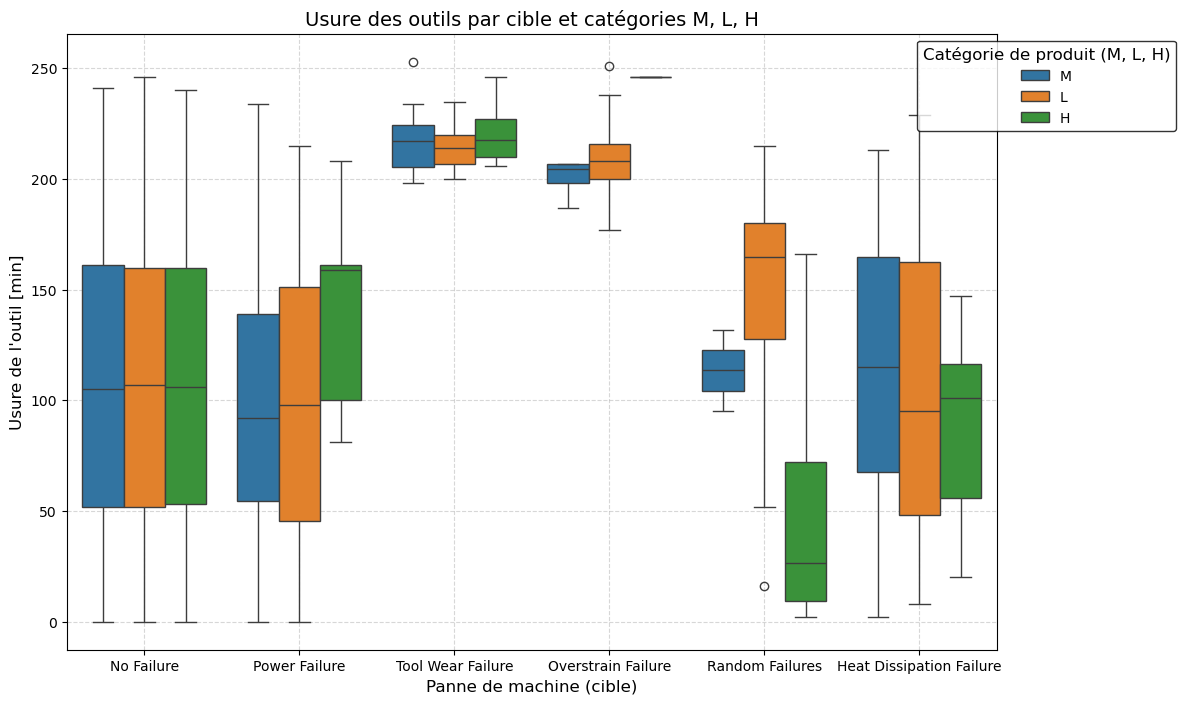

In [15]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.boxplot(data=PDM_data, x='Failure Type', y='Tool wear [min]', hue='Type', ax=ax)
plt.title('Usure des outils par cible et catégories M, L, H', fontsize=14)
plt.xlabel('Panne de machine (cible)', fontsize=12)
plt.ylabel("Usure de l'outil [min]", fontsize=12)
legend = ax.legend(title='Catégorie de produit (M, L, H)', fontsize=10, title_fontsize=12, loc='upper right', bbox_to_anchor=(1.2, 1))
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('black')
ax.grid(True, linestyle='--', alpha=0.5)


**Tool Wear Failure :**  
Les trois catégories (L, M, H) montrent des médianes différentes, avec la catégorie H présentant des temps d'usure des outils plus élevés que M et L. Bien qu'il n'y ait pas de grande différence dans la variabilité, on observe que les produits de qualité supérieure (H) semblent avoir une usure plus importante par rapport aux produits de qualité inférieure (L).

**Power Failure et Overstrain Failure :**  
Les catégories L et H ont des valeurs médianes plus élevées et plus de variabilité par rapport à M. Ça veut dire qu'il y a plus de variations dans les temps d'usure des outils pour ces types de pannes, tandis que M reste plus stable.

**Random Failures :**  
La catégorie H a une médiane très basse et une grande variabilité, ce qui montre que les pannes arrivent avec de faibles temps d'usure des outils et de manière irrégulière. M a une médiane plus haute et une variabilité plus faible, tandis que L montre un comportement entre les deux avec une variabilité modérée.

**Heat Dissipation Failure :**  
La catégorie H a aussi une médiane basse et une grande variabilité, montrant que les pannes arrivent tôt avec un modèle irrégulier. Les catégories M et L ont des médianes plus élevées et des distributions plus régulières.



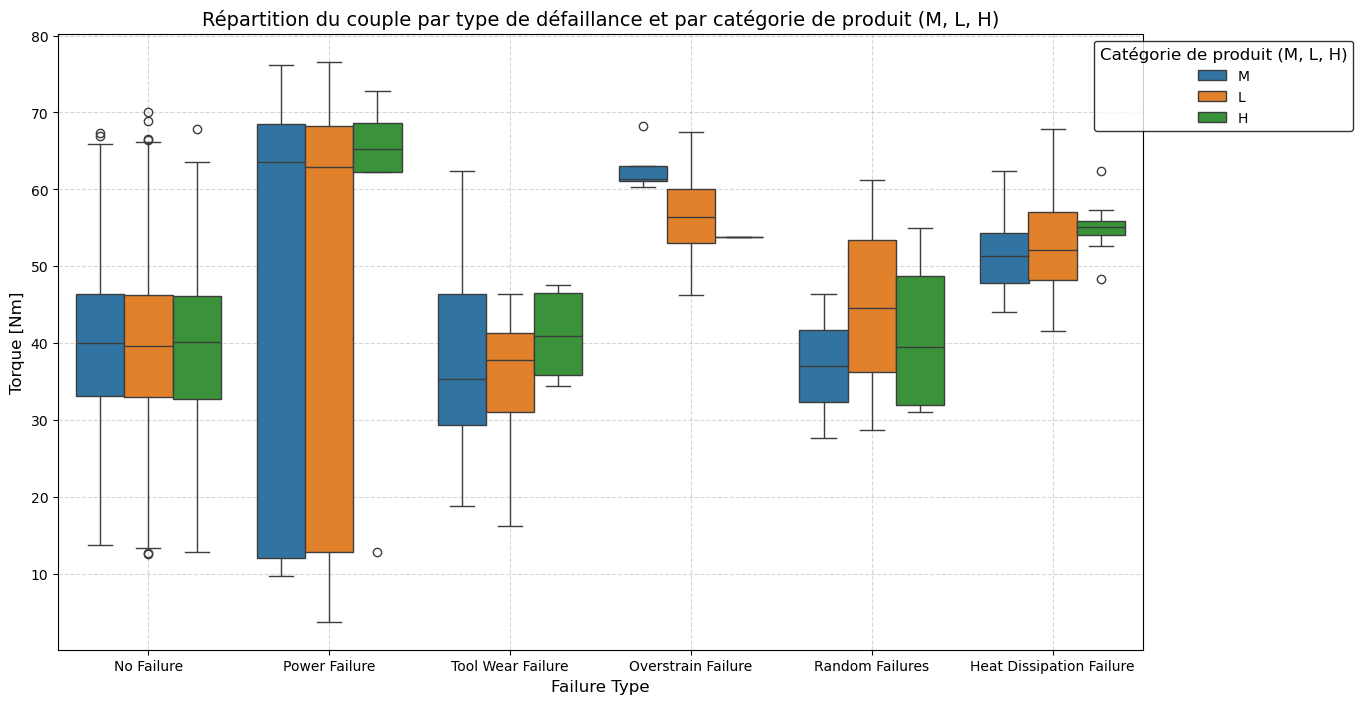

In [16]:
fig, ax = plt.subplots(figsize=(14, 8))
sns.boxplot(data=PDM_data, x='Failure Type', y='Torque [Nm]', hue='Type', ax=ax)
plt.title('Répartition du couple par type de défaillance et par catégorie de produit (M, L, H)', fontsize=14)
plt.xlabel('Failure Type', fontsize=12)
plt.ylabel('Torque [Nm]', fontsize=12)
legend = ax.legend(title='Catégorie de produit (M, L, H)', fontsize=10, title_fontsize=12, loc='upper right', bbox_to_anchor=(1.2, 1))
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('black')
ax.grid(True, linestyle='--', alpha=0.5)

- **Pas de panne (No Failure) :**  
   - Les médianes des trois catégories (M, L, H) sont proches, autour de 40 Nm.  
   - On observe une variabilité importante, avec une plage allant de 12 Nm à 65 Nm. 

- **Panne de puissance (Power Failure) :**   
   - Les catégories M (Moyenne) et L (Basse) montrent une dispersion particulièrement élevée, indiquant une instabilité du couple lors de ces pannes.  
   - Cette variabilité suggère une relation non linéaire entre le couple et d'autres paramètres de panne.

- **Panne d'usure des outils (Tool Wear Failure) :**  
   - Les produits de meilleure qualité (H) montrent un couple légèrement plus élevé au moment de la panne.

- **Panne de surcharge (Overstrain Failure) :**  
   - Médianes élevées.  
   - La variabilité est relativement faible, indiquant un comportement du couple plus prévisible dans ce type de panne.  

- **Pannes aléatoires (Random Failures) :**  
   - Médianes dispersées.  

Le graphique "Relation entre Vitesse de Rotation et Torque par Type de Panne" montre comment chaque type de panne est lié à des plages spécifiques de vitesse et de couple, ce qui aide à repérer les zones à surveiller pour mieux anticiper les pannes.

Retrait des "No Failure" pour une meilleure lecture du graphique

In [17]:
filtered_data = PDM_data[PDM_data['Failure Type'] != "No Failure"]


Text(0.5, 1.0, 'Relation entre Vitesse de Rotation et Torque par Type de Panne')

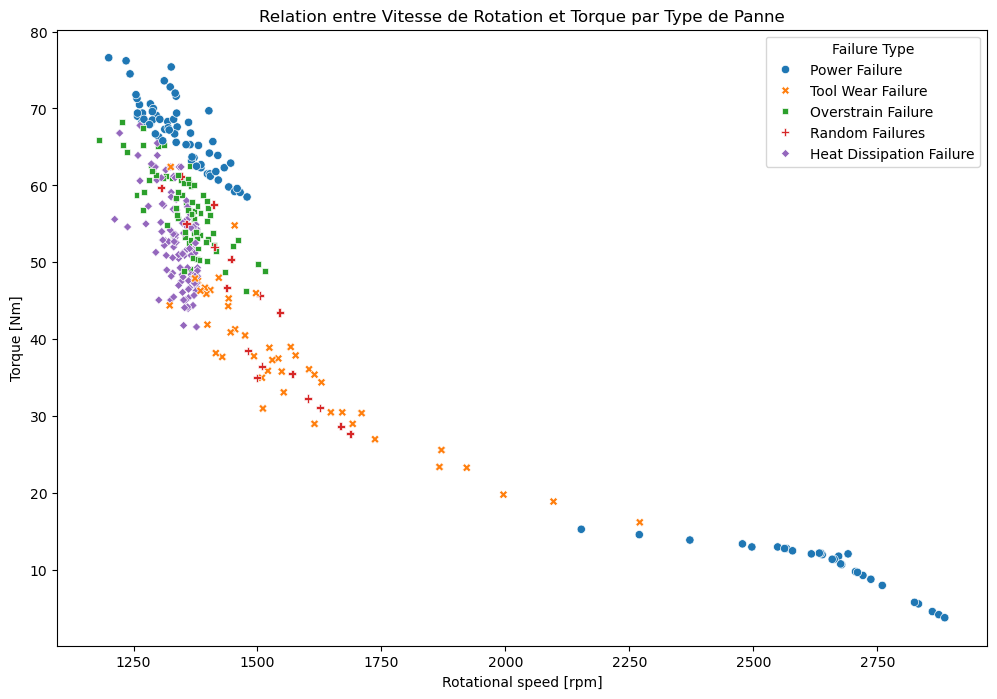

In [18]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=filtered_data, x='Rotational speed [rpm]', y='Torque [Nm]', hue='Failure Type', style='Failure Type')
plt.title('Relation entre Vitesse de Rotation et Torque par Type de Panne')

**Zones critiques**  
- Vitesse faible & couple élevé : Problèmes de dissipation thermique, de surcharge et de puissance
- Vitesse élevée & couple faible : Pannes de puissance.

 


**Conlusion**

L'analyse montre des tendances claires pour certaines pannes, comme celles de puissance et de dissipation thermique, qui surviennent aux extrêmes de la vitesse et du couple, tandis que les pannes aléatoires sont plus difficiles à analyser à cause de leur grande variabilité.

# 5.0 Feature Engineering

Comme vu dans l'analyse des données, les pannes aléatoires ("Random Failures") sont trop imprévisibles pour être bien modélisées. Pour améliorer les modèles, mieux vaut les retirer et les analyser de côté avec des techniques non supervisées. Quand on compare les résultats avec ou sans ces pannes, on voit clairement que l'apprentissage supervisé donne de meilleurs résultats sans elles.

In [19]:
# Filtrer les lignes sans "Random Failure"
PDM_data = PDM_data[PDM_data['Failure Type'] != 'Random Failures']

# Vérifier la répartition des labels après filtrage
print(PDM_data['Failure Type'].value_counts())
print(PDM_data['Target'].value_counts())


Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Name: count, dtype: int64
Target
0    9643
1     339
Name: count, dtype: int64


## 5.1 Encodage de la colonne "Type" et "Product ID"

Ce code encode les lettres du Product ID (L = 0, M = 1, H = 2) ainsi que la colonne "Type" pour transformer ces informations en valeurs numériques. L'identifiant produit devient entièrement numérique pour faciliter son utilisation par les modèles d'apprentissage automatique. Les colonnes temporaires créées lors du processus sont supprimées pour garder un DataFrame propre.

In [20]:
# Vérification et Extraction de lettres et chiffres du "Product ID"
if PDM_data['Product ID'].dtype == 'object':
    # Extraire la première lettre et les chiffres du Product ID
    PDM_data["Product_Letter"] = PDM_data["Product ID"].str[0]  # Extraire la première lettre
    PDM_data["Product_Number"] = PDM_data["Product ID"].str[1:].astype(int)  # Extraire les chiffres

    # Mapping pour encoder les lettres (Product ID et Type)
    letter_mapping = {'H': 3, 'L': 1, 'M': 2}

    # Encodage manuel des lettres du Product ID
    PDM_data['Product_Letter_encoded'] = PDM_data['Product_Letter'].map(letter_mapping)

    # Encodage manuel des lettres de la colonne "Type"
    PDM_data["Type_encoded"] = PDM_data["Type"].map(letter_mapping)

    # Reconstruction du Product_ID en ajoutant l'encodage de la colonne Type
    PDM_data['Product ID'] = (
        PDM_data['Product_Letter_encoded'].astype(int) * 100000 + 
        PDM_data['Product_Number'].astype(int)
    )
    PDM_data['Type'] = PDM_data["Type_encoded"].astype(int)  # Inclure l'encodage du Type
    print(PDM_data)

    # Suppression des colonnes intermédiaires inutiles
    PDM_data.drop(columns=['Product_Letter', 'Product_Number', 'Product_Letter_encoded',"Type_encoded" ], inplace=True)
print(PDM_data)


        UDI  Product ID  Type  Air temperature [K]  Process temperature [K]  \
0         1      214860     2                298.1                    308.6   
1         2      147181     1                298.2                    308.7   
2         3      147182     1                298.1                    308.5   
3         4      147183     1                298.2                    308.6   
4         5      147184     1                298.2                    308.7   
...     ...         ...   ...                  ...                      ...   
9995   9996      224855     2                298.8                    308.4   
9996   9997      339410     3                298.9                    308.4   
9997   9998      224857     2                299.0                    308.6   
9998   9999      339412     3                299.0                    308.7   
9999  10000      224859     2                299.0                    308.7   

      Rotational speed [rpm]  Torque [Nm]  Tool wea

C:\Users\Matte\AppData\Local\Temp\ipykernel_30456\1894010530.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PDM_data["Product_Letter"] = PDM_data["Product ID"].str[0]  # Extraire la première lettre
C:\Users\Matte\AppData\Local\Temp\ipykernel_30456\1894010530.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PDM_data["Product_Number"] = PDM_data["Product ID"].str[1:].astype(int)  # Extraire les chiffres
C:\Users\Matte\AppData\Local\Temp\ipykernel_30456\1894010530.py:11: SettingWithCopyWarning: 
A valu

## 5.2 Data Split: Train and Test

Ce code prépare les données pour l'entraînement en définissant les caractéristiques (X) et deux cibles distinctes (Target et Failure Type). Les données sont divisées en ensembles d'entraînement et de test avec une taille de test de 0.1 (10 %), ce qui signifie que 10 % des données sont réservées pour l'évaluation et 90 % pour l'entraînement. La stratification garantit que la répartition des classes reste la même dans les ensembles, et cette proportion est adaptée à un petit jeu de données pour maximiser les données d'entraînement et améliorer la flexibilité des modèles.

Avec un test_size = 0.2 (20 %), les résultats d'évaluation seraient plus représentatifs, en particulier pour des cibles multi-classes comme Failure Type. Cependant, cela réduirait les données disponibles pour l'entraînement, ce qui pourrait limiter les performances sur un jeu de données réduit.

En conclusion, une taille de test de 0.1 est idéale pour ce projet, car elle maximise les données d'entraînement tout en conservant un ensemble de test suffisant pour évaluer les modèles.

Une comparaison des résultats entre une taille de test de 0.1 et 0.2 est disponible dans le chapitre Résultats.

On split avant de standardiser et d'encoder pour éviter une data leaks des données de test vers l'entraînement, garantissant une évaluation réaliste des modèles.

In [21]:
# Définir les caractéristiques et les cibles
X = PDM_data.drop(columns=['Target', 'Failure Type'])
y_target = PDM_data['Target']
y_failure_type = PDM_data['Failure Type']

# Split pour la cible Target
X_train_target, X_test_target, y_train_target, y_test_target = train_test_split(
    X, y_target, test_size=0.1, random_state=42, stratify=y_target
)

# Split pour la cible Failure Type
X_train_failure, X_test_failure, y_train_failure, y_test_failure = train_test_split(
    X, y_failure_type, test_size=0.1, random_state=42, stratify=y_failure_type
)

## 5.3 Standardisation des données

Ce code crée une pipeline pour préparer les données avant de les utiliser dans les modèles. Il standardise les colonnes numériques pour qu'elles soient sur la même échelle, tout en laissant les autres colonnes inchangées. L'encodage des colonnes "Type" et "Product ID" a déjà été effectué séparément, car ce sont des encodages simples qui ne nécessitent pas d'être inclus dans la pipeline.

In [22]:
# Séléction des colonnes à standardiser 
numeric_columns = [
    'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 
    'Torque [Nm]', 'Tool wear [min]', 'Temp_Diff [K]', 'Power [W]'
]
print("Colonnes à standardiser :", numeric_columns)

# Prétraitement avec Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), numeric_columns)  # Standardiser uniquement numeric_columns
    ],
    remainder="passthrough"  # Conserver les autres colonnes telles quelles (Type, etc.)
)

Colonnes à standardiser : ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temp_Diff [K]', 'Power [W]']


Ce code applique un pipeline de prétraitement pour transformer les données d'entraînement et de test de manière cohérente, en ajustant les transformations sur l'entraînement et en les appliquant au test. Cela garantit une préparation uniforme des données tout en évitant les fuites.

In [23]:
# Transformation des Données pour la cible Target
X_train_target_preprocessed = preprocessor.fit_transform(X_train_target)
X_test_target_preprocessed = preprocessor.transform(X_test_target)

# Transformation des Données pour la cible Failure Type
X_train_failure_preprocessed = preprocessor.fit_transform(X_train_failure)
X_test_failure_preprocessed = preprocessor.transform(X_test_failure)

print(X_train_target_preprocessed[:5])
print(X_train_failure_preprocessed[:5])

[[-9.46456016e-01 -1.48376630e+00 -7.97746173e-02 -4.05503986e-01
   3.80376561e-01 -3.02065904e-01 -5.07486008e-01  9.95900000e+03
   2.24818000e+05  2.00000000e+00]
 [-3.47276036e-01  3.38713556e-01 -5.74371028e-02  1.36726225e-01
  -1.42486950e+00  1.19482168e+00  3.17485630e-01  9.58500000e+03
   1.56764000e+05  1.00000000e+00]
 [-8.96524351e-01 -1.48376630e+00  2.55288100e-01 -5.36040889e-01
  -4.67304197e-01 -4.01858410e-01 -4.98303507e-01  1.71600000e+03
   1.48895000e+05  1.00000000e+00]
 [ 3.51767273e-01 -2.01280476e-01  3.27885022e-01 -6.26412591e-01
   6.47239022e-01 -1.00061344e+00 -5.95372859e-01  2.92100000e+03
   1.50100000e+05  1.00000000e+00]
 [ 3.51767273e-01  1.36215794e-01  8.75154127e-01 -1.24897320e+00
  -5.45793156e-01 -5.01650915e-01 -1.30371200e+00  6.45200000e+03
   1.53631000e+05  1.00000000e+00]]
[[ 1.80476912e+00  1.21951105e+00  6.70540213e-01 -5.32678952e-01
  -2.22062588e-01 -1.80322453e+00 -2.37477195e-01  4.68200000e+03
   2.19541000e+05  2.00000000e+0

Ce code crée une liste transformed_columns qui regroupe les noms des colonnes après transformation. Il inclut les colonnes encodées (Type), les colonnes numériques standardisées (comme Air temperature [K]), et toutes les autres colonnes non transformées. Cette liste est utilisée pour reconstruire un DataFrame avec des noms alignés sur les transformations appliquées.

In [24]:
transformed_columns = (
   [f"{col}" for col in ["Type"]] +  # Colonnes encodées
    [f"{col}" for col in [
        'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 
        'Torque [Nm]', 'Tool wear [min]', 'Temp_Diff [K]', 'Power [W]'
    ]] +  # Colonnes standardisées
    [col for col in X.columns if col not in numeric_columns and col != "Type"]  # Autres colonnes
)

Ce code reconstruit les DataFrames X_train_target, X_test_target, X_train_failure et X_test_failure à partir des données transformées en leur assignant des noms de colonnes définis dans transformed_columns. Cela permet d'avoir des données prêtes pour  l'entraînement avec des colonnes bien identifiées.

In [25]:
# Reconstruction du DataFrame  à partir des données prétraitées `preprocessed`,
# avec les mêmes noms de colonnes issus de transformed_columns.
transformed_columns = numeric_columns + ['UDI', 'Product ID', 'Type']

X_train_target = pd.DataFrame(X_train_target_preprocessed, columns=transformed_columns)
X_test_target = pd.DataFrame(X_test_target_preprocessed, columns=transformed_columns)

X_train_failure = pd.DataFrame(X_train_failure_preprocessed, columns=transformed_columns)
X_test_failure = pd.DataFrame(X_test_failure_preprocessed, columns=transformed_columns)

Ce code vérifie que les colonnes transformées sont bien alignées avec leurs noms dans le DataFrame final. La première ligne montre les colonnes qui ont été spécifiquement passées à StandardScaler pour la standardisation. La deuxième ligne affiche l'ordre des colonnes utilisé lors de la reconstruction du DataFrame final après transformation.

In [26]:
print("Colonnes utilisées par StandardScaler :", numeric_columns)
print("Colonnes alignées avec les données :", transformed_columns)

Colonnes utilisées par StandardScaler : ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temp_Diff [K]', 'Power [W]']
Colonnes alignées avec les données : ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temp_Diff [K]', 'Power [W]', 'UDI', 'Product ID', 'Type']


Ce code affiche les 5 premières lignes de chaque DataFrame transformé pour vérifier la cohérence et l'exactitude des transformations appliquées.

In [27]:
# Aperçu des 5 premières lignes pour chaque DataFrame
print("X_train_target :\n", X_train_target.head(), "\n")
print("X_test_target :\n", X_test_target.head(), "\n")
print("X_train_failure :\n", X_train_failure.head(), "\n")
print("X_test_failure :\n", X_test_failure.head(), "\n")

X_train_target :
    Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0            -0.946456                -1.483766               -0.079775   
1            -0.347276                 0.338714               -0.057437   
2            -0.896524                -1.483766                0.255288   
3             0.351767                -0.201280                0.327885   
4             0.351767                 0.136216                0.875154   

   Torque [Nm]  Tool wear [min]  Temp_Diff [K]  Power [W]     UDI  Product ID  \
0    -0.405504         0.380377      -0.302066  -0.507486  9959.0    224818.0   
1     0.136726        -1.424869       1.194822   0.317486  9585.0    156764.0   
2    -0.536041        -0.467304      -0.401858  -0.498304  1716.0    148895.0   
3    -0.626413         0.647239      -1.000613  -0.595373  2921.0    150100.0   
4    -1.248973        -0.545793      -0.501651  -1.303712  6452.0    153631.0   

   Type  
0   2.0  
1   1.0  
2   1.0  
3   

Ce code utilise la fonction LabelEncoder pour transformer les target en valeurs numériques, pour qu'ils puissent être utilisé dans les modèles.On utilise LabelEncoder parce qu’il est simple pour convertir une cible avec peu de classes en nombres entiers.

In [28]:
label_encoder_failure = LabelEncoder()
y_train_failure_encoded = label_encoder_failure.fit_transform(y_train_failure)
y_test_failure_encoded = label_encoder_failure.transform(y_test_failure)

Ce code vérifie et affiche les résultats des transformations appliquées aux target et features. Il affiche le mapping entre les classes originales et leurs valeurs encodées, donne un aperçu des targets encodés, et valide les targets originales. Il inspecte également les types de données des colonnes dans les ensembles d'entraînement pour s'assurer que tout est conforme.

In [29]:
# Afficher le mapping
label_mapping = dict(zip(label_encoder_failure.classes_, label_encoder_failure.transform(label_encoder_failure.classes_)))
for label, encoded in label_mapping.items():
    print(f"{label} → {encoded}")

# Aperçu des labels encodés
print(pd.Series(y_train_failure_encoded).head())
print(pd.Series(y_test_failure_encoded).head())
# Validation des transformations finales des target
print("Aperçu de y_train_target après prétraitement final :")
print(y_train_target)

print("Aperçu de y_train_failure après prétraitement final :")
print(y_train_failure)

# Vérification des types de données des features
print("Types de données dans X_train_target :")
print(X_train_target.dtypes)

print("Types de données dans X_train_failure :")
print(X_train_failure.dtypes)

Heat Dissipation Failure → 0
No Failure → 1
Overstrain Failure → 2
Power Failure → 3
Tool Wear Failure → 4
0    1
1    1
2    1
3    1
4    1
dtype: int64
0    1
1    1
2    1
3    1
4    1
dtype: int64
Aperçu de y_train_target après prétraitement final :
9958    0
9584    0
1715    0
2920    0
6451    0
       ..
5676    0
7573    0
6238    0
1709    0
3805    0
Name: Target, Length: 8983, dtype: int64
Aperçu de y_train_failure après prétraitement final :
4681    No Failure
5004    No Failure
2160    No Failure
639     No Failure
9087    No Failure
           ...    
7847    No Failure
1605    No Failure
8234    No Failure
6016    No Failure
9730    No Failure
Name: Failure Type, Length: 8983, dtype: object
Types de données dans X_train_target :
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]     float64
Torque [Nm]                float64
Tool wear [min]            float64
Temp_Diff [K]              float64
Power [W]                  float6

On retire les colonnes UDI, Product ID, et Type car elles ne représentent pas des données issues de capteurs machines et n'ont pas de lien direct avec le comportement ou l'état de la machine. Ces colonnes sont des identifiants qui pourraient introduire du biais dans les modèles. Pour la détection d'anomalies, on se concentre uniquement sur les données issues des capteurs, qui reflètent directement le fonctionnement de la machine.

In [30]:
X_train_target_clean = X_train_target.drop(columns=['UDI', 'Product ID', 'Type'], errors='ignore').copy()
X_test_target_clean = X_test_target.drop(columns=['UDI', 'Product ID', 'Type'], errors='ignore').copy()

X_train_failure_clean = X_train_failure.drop(columns=['UDI', 'Product ID', 'Type'], errors='ignore').copy()
X_test_failure_clean = X_test_failure.drop(columns=['UDI', 'Product ID', 'Type'], errors='ignore').copy()

Ce code applique une PCA pour réduire les dimensions des données Target et Failure, en conservant 7 composantes principales. Ce choix correspond au nombre de colonnes du DataFrame, ce qui garantit que toute l'information est préservée.

In [31]:
# Appliquer PCA sur les données Target
pca_target = PCA(n_components= 7)  # Conserve 95% de la variance
X_train_pca_target = pca_target.fit_transform(X_train_target_clean)
X_test_pca_target = pca_target.transform(X_test_target_clean)

# Appliquer PCA sur les données Failure
pca_failure = PCA(n_components= 7)  # Conserve 95% de la variance
X_train_pca_failure = pca_failure.fit_transform(X_train_failure_clean)
X_test_pca_failure = pca_failure.transform(X_test_failure_clean)

Le choix de garder 7 composantes pour la PCA a été fait après avoir testé une réduction à 95 % de la variance, qui a donné de moins bons résultats. Avec 0.95, des dimensions avec une faible variance sont supprimées, ce qui peut faire perdre des infos importantes, surtout avec un petit dataset comme le nôtre. En gardant 7 composantes, toutes les informations sont préservées, même celles avec moins de variance, ce qui améliore les performances des modèles. Cela montre que, sur un petit dataset, garder toutes les dimensions peut éviter de perdre des patterns utiles.

Ce code affiche un aperçu des données transformées après application de la PCA pour les cibles Target et Failure. Il montre les premières lignes des ensembles d'entraînement et de test  pour vérifier la transformation. Ensuite, il affiche la variance expliquée par chaque composante principale et le nombre de composantes retenues pour les deux cas (Target et Failure). Cela permet de confirmer que la PCA n'a pas réduit les dimensions.

In [32]:
# Affichage des premières lignes après PCA pour Target
print("Aperçu de X_train_pca_target :")
print(X_train_pca_target[:7])
print("Aperçu de X_test_pca_target :")
print(X_test_pca_target[:7])

# Affichage des premières lignes après PCA pour Failure
print("\nAperçu de X_train_pca_failure :")
print(X_train_pca_failure[:5])
print("Aperçu de X_test_pca_failure :")
print(X_test_pca_failure[:5])

# Afficher les variances expliquées
print("\n Variance expliquée par PCA (Target) :", pca_target.explained_variance_ratio_)
print(" Nombre de composantes (Target) :", pca_target.n_components_)
print("\n Variance expliquée par PCA (Failure) :", pca_failure.explained_variance_ratio_)
print(" Nombre de composantes (Failure) :", pca_failure.n_components_)

Aperçu de X_train_pca_target :
[[-3.94755864e-01 -1.34831229e+00  3.87205756e-01 -1.20761797e+00
  -4.23496398e-01 -1.46352520e-02 -1.05387172e-15]
 [ 3.52443911e-01 -6.22564803e-01 -1.40015863e+00  1.14425988e+00
   1.57072595e-01 -9.85867212e-02  7.14045529e-16]
 [-6.51885724e-01 -1.29672536e+00 -4.65827929e-01 -1.27470133e+00
  -1.84173368e-01 -6.13950038e-02 -1.09728202e-15]
 [-9.46554464e-01  5.51065033e-01  6.21845017e-01 -8.98030805e-01
  -2.06386972e-01 -5.81864569e-02 -6.11452709e-16]
 [-2.01645452e+00  3.98262672e-01 -5.70256093e-01 -2.85474852e-01
  -2.93151246e-01 -2.23949377e-03 -2.42871763e-16]
 [-2.45055458e-01 -1.21716697e-01 -1.09094488e+00  1.85482899e+00
   1.94487646e-01 -1.23000079e-01  1.25186740e-15]
 [ 8.57076364e-01  5.04897651e-01  1.05670587e+00  3.72609813e-01
   3.82893863e-01 -1.11776895e-01  3.40696069e-16]]
Aperçu de X_test_pca_target :
[[-9.04703475e-01  2.37361906e-01 -2.36479035e-01  1.58929939e+00
  -6.36976415e-01  1.82084608e-02  1.20852210e-15]
 [

Les résultats montrent que la PCA a transformé les données dans un nouvel espace orthogonal, mais sans réduction des dimensions comme voulu, car 7 composantes principales ont été conservées pour 7 colonnes d'origine. La variance expliquée par chaque composante indique comment les informations sont réparties entre ces dimensions. Cela confirme que toutes les informations initiales ont été préservées, ce qui est attendu avec un choix de composantes égal au nombre total de colonnes.

# 6.0 Modélisation des modèles pour une tâche binaire

On va entraîner des modèles pour détecter les pannes target 1 ou 0. L'idée est de comparer les performances des modèles avec et sans SMOTE pour voir comment l'équilibrage des classes influence les résultats. Pour chaque modèle, on analysera les prédictions avec une matrice de confusion, en regardant de près les faux positifs et les faux négatifs et on analysera le modèle le plus adapté en fonction des résultats

## 6.1 Application de SMOTE

Dans ce code, SMOTE est appliqué pour résoudre le problème des classes déséquilibrées, SMOTE gère le déséquilibre des classes en générant des exemples synthétiques pour améliorer l'apprentissage des classes minoritaires, il aide le modèle à mieux apprendre les classes minoritaires, ce qui améliore des métriques comme le rappel ou le F1-score. C'est une méthode simple et utile, notamment pour notre dataset avec une classe minoritaire de pannes. Cependant, elle peut introduire du bruit et ralentir l'entraînement en augmentant la taille des données.

Les paramètres choisis pour SMOTE visent à équilibrer les classes efficacement. Avec sampling_strategy=0.7, la classe minoritaire atteint 70 % de la classe majoritaire, limitant le bruit. random_state=42 assure la reproductibilité, et k_neighbors=3 génère des exemples proches pour mieux représenter les classes minoritaires peu denses.

Avec une stratégie d'échantillonnage de 0.7, la précision s'améliore légèrement au prix d'une petite baisse du rappel, offrant un équilibre global satisfaisant. En comparaison, un échantillonnage de 1 (classes parfaitement équilibrées) avec SMOTE a donné un rappel légèrement plus élevé mais une baisse plus marquée de la précision. Cela s'explique par une génération excessive d'exemples synthétiques, augmentant les Faux Positifs. L'échantillonnage partiel (0.7) est donc préféré pour mieux équilibrer les performances entre précision et rappel.

In [33]:
# Assurer que les labels sont sous forme entière
y_train_target = y_train_target.astype(int)
y_test_target = y_test_target.astype(int)

# SMOTE : Oversampling sur les données d'entraînement
smote_target = SMOTE(sampling_strategy=0.7, random_state=42, k_neighbors=3)
X_train_target_resampled, y_train_target_resampled = smote_target.fit_resample(X_train_pca_target, y_train_target)

print(pd.Series(y_train_target_resampled).value_counts())

Target
0    8678
1    6074
Name: count, dtype: int64


Après l'application de SMOTE, les résultats montrent que la classe minoritaire (1) a été augmentée à 70 % de la taille de la classe majoritaire (0)

Dans des tâches comme la prédiction de pannes, le rappel est privilégié pour les raisons suivantes :

Coût élevé des Faux Négatifs (FN) :
- Un Faux Négatif se produit lorsque le modèle ne détecte pas une panne réelle.
Cela peut entraîner des réparations coûteuses, des temps d'arrêt de la machine non planifiés, et des impacts majeurs sur les opérations.
Les conséquences d'une panne non détectée sont souvent que le coût d'une intervention peu utile.

- Impact plus faible des Faux Positifs (FP) :
Un Faux Positif se produit lorsque le modèle prédit une panne qui n'existe pas.
Cela peut engendrer des vérifications ou des maintenances inutiles, mais les coûts et l'impact opérationnel restent faibles en comparaison à une panne  non détectée.
- Pourquoi préférer les Faux Positifs ?
En maintenance prédictive, maximiser le rappel garantit qu’un maximum de pannes sont détectées, même si cela implique quelques interventions inutiles. Cette approche réduit le risque d’incidents critiques, ce qui est essentiel pour minimiser les impacts financiers et opérationnels.

## 6.2 Modèles entraînés


Nous allons évaluer plusieurs modèles de classification pour déterminer lequel est le mieux adapté à notre cas :

- Random Forest : Combine plusieurs arbres de décision pour réduire la variance et éviter le surajustement. Avec la variable "Balance", il ajuste les poids pour mieux gérer le déséquilibre des classes et améliorer le rappel.

- Logistic Regression : Modèle linéaire qui estime les probabilités pour une classification binaire.

- Gradient Boosting : Construit des arbres séquentiels, chaque arbre corrigeant les erreurs du précédent, offrant une grande précision.

- XGBoost : Version optimisée de Gradient Boosting, ayant une régularisation pour éviter le surajustement.

- LightGBM : Variante plus rapide de Gradient Boosting, adaptée aux grands jeux de données avec des variables catégoriques.

### 6.2.1 Modèles entraînés sans SMOTE

Ce code configure des modèles de classification sans l'application de SMOTE, certains avec l'option balanced pour mieux gérer le déséquilibre des classes. Les modèles balanced favorisent la détection des classes minoritaires, tandis que les non-balanced peuvent fausser les résultats en faveur de la classe majoritaire.

In [34]:
# Liste des modèles sans application de SMOTE
models = {
    "Random Forest (Balanced)": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42, n_jobs=-1, max_iter=2000, C=0.1, solver='saga'),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', objective= "binary:logistic", random_state=42, n_jobs=-1, scale_pos_weight= 1.42),
    "LightGBM": LGBMClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
}

Ce code entraîne plusieurs modèles sans SMOTE, les stocke dans un dictionnaire, et génère des prédictions (y_pred_target) ainsi que des probabilités associées (y_proba_target) sur les données d'entraînement. Les prédictions permettent d'évaluer la capacité du modèle à classer correctement, tandis que les probabilités donnent une mesure de confiance dans chaque prédiction, utiles pour des analyses plus fines comme le calcul du ROC-AUC.

In [35]:
trained_models_without_smote = {}

for name, model in models.items():
    # Train each model using the training data
    model.fit(X_train_pca_target, y_train_target)
    
    # Store the trained model in the dictionary, with the model name as the key
    trained_models_without_smote[name] = model

    # Make predictions on the test data (X_test)
    y_pred_target = model.predict(X_train_pca_target)
    y_proba_target = model.predict_proba(X_train_pca_target)[:, 1] if hasattr(model, 'predict_proba') else np.zeros_like(y_pred_target)


[LightGBM] [Info] Number of positive: 305, number of negative: 8678
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000866 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 8983, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


### 6.2.2 Modèles entraînés avec SMOTE

Ce code définit une liste de modèles de classification entraînés avec des données équilibrées par SMOTE.Le paramètre n_jobs=-1 permet d'utiliser tous les cœurs du processeur pour accélérer l'entraînement des modèles en parallélisant les calculs.

In [36]:
models_with_smote = {
    "Random Forest (SMOTE)": RandomForestClassifier(random_state=42, n_jobs=-1),
    "Gradient Boosting (SMOTE)": GradientBoostingClassifier(random_state=42),
    "Logistic Regression (SMOTE)": LogisticRegression(class_weight='balanced', random_state=42, n_jobs=-1, max_iter=2000, C=0.1, solver='saga'),
    "XGBoost (SMOTE)": XGBClassifier(eval_metric='logloss', objective= "binary:logistic", random_state=42, n_jobs=-1, scale_pos_weight= 1.42),
    "LightGBM (SMOTE)": LGBMClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
}

Ce code entraîne les modèles définis avec SMOTE sur les données équilibrées X_train_target_resampled, y_train_target_resampled et stocke chaque modèle entraîné dans un dictionnaire.

In [37]:
trained_models_with_smote = {}

for name, model in models_with_smote.items():
    trained_model = model.fit(X_train_target_resampled, y_train_target_resampled)
    trained_models_with_smote[name] = trained_model

[LightGBM] [Info] Number of positive: 6074, number of negative: 8678
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000323 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 14752, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


Cette sortie montre que LightGBM a ajusté automatiquement les paramètres pour optimiser les performances (parallélisation, initialisation). Elle confirme que les données d'entraînement sont correctement configurées après SMOTE, avec 7 caractéristiques et un total de 14752 points répartis entre 6074 positifs et 8678 négatifs.

## 6.3 Évaluer et comparer

les modèles seront évalués et comparés sur plusieurs métriques, le rappel, la précision, et le F2-score, pour analyser leurs performances globales. Une attention particulière sera portée sur la différence entre les résultats obtenus avec et sans l'application de SMOTE, afin de comprendre l'impact de l'équilibrage des classes sur les prédictions. Cette comparaison permettra de déterminer quel modèle, et quelle approche, est le mieux adapté à notre dataset et à notre objectif de détection de pannes.

1. Performances globales :

Sur les données de test :

- Accuracy : Pourcentage de prédictions correctes (toutes classes confondues). Cependant, dans un dataset déséquilibré, elle est peu pertinente.
- Précision : Proportion de prédictions positives correctes parmi toutes les prédictions positives. Indique la fiabilité des alertes de panne.
- Rappel : Proportion de pannes correctement détectées parmi toutes les pannes réelles. Crucial en maintenance prédictive pour minimiser les pannes non détectées.
- F2-Score : Combine rappel et précision, avec un poids plus élevé sur le rappel, pour évaluer la capacité à détecter un maximum de pannes.
- ROC-AUC : Mesure la capacité du modèle à distinguer entre classes positives et négatives à différents seuils de probabilité.

Sur les données d'entraînement : Ces mêmes métriques sont calculées pour détecter d'éventuels problèmes comme le surajustement (overfitting), où le modèle performe très bien sur l'entraînement mais échoue sur le test.

2. Écarts (gaps) :
Les écarts entre les performances d'entraînement et de test permettent d'évaluer la généralisation du modèle :

- Accuracy Gap : Différence entre l'accuracy sur l'entraînement et sur le test. Un écart important peut indiquer un surajustement.
- Precision Gap : Évalue si le modèle est plus fiable à prédire correctement les classes positives en entraînement qu'en test.
- Recall Gap : Indique si le modèle détecte moins bien les pannes (positifs) en test, révélant un manque de généralisation.
- F2-Score Gap : Mesure globale de l'équilibre entre rappel et précision sur les deux ensembles. Un grand écart peut signaler des problèmes dans la structure des données ou un surajustement.

Le F2-Score donne plus de poids au rappel qu'à la précision. Il est utile dans des contextes comme la maintenance prédictive, où il est important de détecter un maximum de pannes et minimiser les Faux Négatifs, même si cela peut entrainer des Faux Positifs.

La validation croisée est utilisée pour évaluer la stabilité et la capacité de généralisation des modèles en testant leurs performances sur plusieurs sous-ensembles de données, réduisant ainsi les risques de surajustement.

### 6.3.1 Évaluation sans SMOTE

Ce code évalue les performances des modèles sans SMOTE en calculant des métriques (Accuracy, Précision, Rappel, F2-Score, ROC-AUC) sur les données de test et d'entraînement, tout en ajoutant une validation croisée pour vérifier la stabilité des modèles. La validation croisée réduit les risques de surajustement et fournit des métriques plus fiables. Les écarts entre entraînement et test détectent le surajustement, et les résultats, triés par rappel, aident à identifier les meilleurs modèles, avec des matrices de confusion pour analyser les erreurs.

In [38]:
# Configuration de la validation croisée
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='binary', zero_division=0),
    'recall': make_scorer(recall_score, average='binary', zero_division=0),
    'f2_score': make_scorer(fbeta_score, beta=2, average='binary', zero_division=0)
}

# Initialisation des listes pour les DataFrames
metrics_results = []  # Contient les métriques globales
gap_results = []  # Contient les écarts entre entraînement et test
cv_results_summary = []  # Contient les résultats de validation croisée
conf_matrices_without_smote = {}

# Évaluation des modèles sans SMOTE
for name, model in trained_models_without_smote.items():
    # Prédictions sur les données de test
    y_pred_test = model.predict(X_test_pca_target)
    y_proba_test = model.predict_proba(X_test_pca_target)[:, 1] if hasattr(model, 'predict_proba') else np.zeros_like(y_pred_test)

    # Prédictions sur les données d'entraînement
    y_pred_train = model.predict(X_train_pca_target)
    y_proba_train = model.predict_proba(X_train_pca_target)[:, 1] if hasattr(model, 'predict_proba') else np.zeros_like(y_pred_train)

    # Calcul des métriques de test
    test_metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test_target, y_pred_test),
        "Precision": precision_score(y_test_target, y_pred_test, average='binary', zero_division=0),
        "Recall": recall_score(y_test_target, y_pred_test, average='binary', zero_division=0),
        "F2-Score": fbeta_score(y_test_target, y_pred_test, average='binary', beta=2, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_target, y_proba_test) if hasattr(model, 'predict_proba') else 'N/A'
    }

    # Calcul des métriques d'entraînement
    train_metrics = {
        "Train_Accuracy": accuracy_score(y_train_target, y_pred_train),
        "Train_Recall": recall_score(y_train_target, y_pred_train, average='binary', zero_division=0),
        "Train_F2-Score": fbeta_score(y_train_target, y_pred_train, average='binary', beta=2, zero_division=0)
    }

    # Calcul des écarts (Gaps)
    gap_metrics = {
        "Model": name,
        "Accuracy_Gap": train_metrics["Train_Accuracy"] - test_metrics["Accuracy"],
        "Recall_Gap": train_metrics["Train_Recall"] - test_metrics["Recall"],
        "F2-Score_Gap": train_metrics["Train_F2-Score"] - test_metrics["F2-Score"]
    }

    # Validation croisée
    scoring_cv = scoring.copy()
    if hasattr(model, 'predict_proba'):
        scoring_cv['roc_auc'] = make_scorer(roc_auc_score, needs_proba=True)
    else:
        scoring_cv.pop('roc_auc', None)

    try:
        cv_results = cross_validate(
            model,
            X_train_pca_target,
            y_train_target,
            cv=cv,
            scoring=scoring_cv,
            return_train_score=True
        )
    except Exception as e:
        print(f"Cross-validation failed for {name}: {e}")
        cv_results = {'test_accuracy': [0], 'test_precision': [0], 'test_recall': [0], 'test_f2_score': [0], 'test_roc_auc': [0]}

    # Résumé des résultats de la validation croisée
    cv_metrics = {
        "Model": name,
        "CV_Accuracy": np.mean(cv_results['test_accuracy']),
        "CV_Precision": np.mean(cv_results['test_precision']),
        "CV_Recall": np.mean(cv_results['test_recall']),
        "CV_F2-Score": np.mean(cv_results['test_f2_score']),
        "CV_ROC-AUC": np.mean(cv_results['test_roc_auc']) if 'test_roc_auc' in scoring_cv else 'N/A'
    }

    # Stockage des résultats dans les listes
    metrics_results.append(test_metrics)
    gap_results.append(gap_metrics)
    cv_results_summary.append(cv_metrics)

    # Stockage des matrices de confusion
    conf_matrices_without_smote[name] = confusion_matrix(y_test_target, y_pred_test)

    print(f"{name} evaluated successfully.\n")

# Création des DataFrames pour chaque ensemble de résultats
metrics_df = pd.DataFrame(metrics_results).sort_values(by='Recall', ascending=False)
gaps_df = pd.DataFrame(gap_results).sort_values(by='Accuracy_Gap', ascending=False)
cv_results_df = pd.DataFrame(cv_results_summary).sort_values(by='CV_Recall', ascending=False)

c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\model_selection\_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\metrics\_scorer.py", line 140, in __call__
    score = scorer._score(
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\metrics\_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\utils\_param_validation.py", line 194, in wrapper
    params = func_sig.bind(*args, **kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\inspect.py", line 3186, in bind
    return self._bind(args, kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\inspect.py", line 3175, in _bind
    raise TypeError(
Type

Random Forest (Balanced) evaluated successfully.



c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\model_selection\_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\metrics\_scorer.py", line 140, in __call__
    score = scorer._score(
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\metrics\_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\utils\_param_validation.py", line 194, in wrapper
    params = func_sig.bind(*args, **kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\inspect.py", line 3186, in bind
    return self._bind(args, kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\inspect.py", line 3175, in _bind
    raise TypeError(
Type

Random Forest evaluated successfully.



c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\model_selection\_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\metrics\_scorer.py", line 140, in __call__
    score = scorer._score(
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\metrics\_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\utils\_param_validation.py", line 194, in wrapper
    params = func_sig.bind(*args, **kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\inspect.py", line 3186, in bind
    return self._bind(args, kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\inspect.py", line 3175, in _bind
    raise TypeError(
Type

...

c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\model_selection\_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\metrics\_scorer.py", line 140, in __call__
    score = scorer._score(
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\metrics\_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\utils\_param_validation.py", line 194, in wrapper
    params = func_sig.bind(*args, **kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\inspect.py", line 3186, in bind
    return self._bind(args, kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\inspect.py", line 3175, in _bind
    raise TypeError(
Type

[LightGBM] [Info] Number of positive: 244, number of negative: 6942
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000383 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 7186, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 244, number of negative: 6943
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000435 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 7187, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\model_selection\_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\metrics\_scorer.py", line 140, in __call__
    score = scorer._score(
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\metrics\_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\utils\_param_validation.py", line 194, in wrapper
    params = func_sig.bind(*args, **kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\inspect.py", line 3186, in bind
    return self._bind(args, kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\inspect.py", line 3175, in _bind
    raise TypeError(
Type

[LightGBM] [Info] Number of positive: 244, number of negative: 6943
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000449 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 7187, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM evaluated successfully.



c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\model_selection\_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\metrics\_scorer.py", line 140, in __call__
    score = scorer._score(
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\metrics\_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\utils\_param_validation.py", line 194, in wrapper
    params = func_sig.bind(*args, **kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\inspect.py", line 3186, in bind
    return self._bind(args, kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\inspect.py", line 3175, in _bind
    raise TypeError(
Type

### 6.3.2 Évaluation avec SMOTE

Ce code évalue les performances des modèles avec SMOTE en utilisant les mêmes métriques et la validation croisée que le code précédent.

In [39]:
# Configuration de la validation croisée
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='binary', zero_division=0),
    'recall': make_scorer(recall_score, average='binary', zero_division=0),
    'f2_score': make_scorer(fbeta_score, beta=2, average='binary', zero_division=0)
}

# Initialisation des listes pour les DataFrames
metrics_results_with_smote = []  # Contient les métriques principales
gap_results_with_smote = []  # Contient les écarts (gaps)
cv_results_summary_with_smote = []  # Contient les résultats de validation croisée
conf_matrices_with_smote = {}

# Évaluation des modèles avec SMOTE
for name, model in trained_models_with_smote.items():

    # Prédictions sur les données de test
    y_pred_test = model.predict(X_test_pca_target)
    y_proba_test = model.predict_proba(X_test_pca_target)[:, 1] if hasattr(model, 'predict_proba') else np.zeros_like(y_pred_test)

    # Prédictions sur les données d'entraînement (après SMOTE)
    y_pred_train = model.predict(X_train_target_resampled)
    y_proba_train = model.predict_proba(X_train_target_resampled)[:, 1] if hasattr(model, 'predict_proba') else np.zeros_like(y_pred_train)

    # Calcul des métriques de test
    test_metrics_with_smote = {
        "Model": name,
        "Accuracy": accuracy_score(y_test_target, y_pred_test),
        "Precision": precision_score(y_test_target, y_pred_test, average='binary', zero_division=0),
        "Recall": recall_score(y_test_target, y_pred_test, average='binary', zero_division=0),
        "F2-Score": fbeta_score(y_test_target, y_pred_test, average='binary', beta=2, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_target, y_proba_test) if hasattr(model, 'predict_proba') else 'N/A'
    }

    # Calcul des métriques d'entraînement
    train_metrics_with_smote = {
        "Train_Accuracy": accuracy_score(y_train_target_resampled, y_pred_train),
        "Train_Precision": precision_score(y_train_target_resampled, y_pred_train, average='binary', zero_division=0),
        "Train_Recall": recall_score(y_train_target_resampled, y_pred_train, average='binary', zero_division=0),
        "Train_F2-Score": fbeta_score(y_train_target_resampled, y_pred_train, average='binary', beta=2, zero_division=0)
    }

    # Calcul des écarts (Gaps)
    gap_metrics_with_smote = {
        "Model": name,
        "Accuracy_Gap": train_metrics_with_smote["Train_Accuracy"] - test_metrics_with_smote["Accuracy"],
        "Precision_Gap": train_metrics_with_smote["Train_Precision"] - test_metrics_with_smote["Precision"],
        "Recall_Gap": train_metrics_with_smote["Train_Recall"] - test_metrics_with_smote["Recall"],
        "F2-Score_Gap": train_metrics_with_smote["Train_F2-Score"] - test_metrics_with_smote["F2-Score"]
    }

    # Validation croisée
    scoring_cv = scoring.copy()
    if hasattr(model, 'predict_proba'):
        scoring_cv['roc_auc'] = make_scorer(roc_auc_score, needs_proba=True)
    else:
        scoring_cv.pop('roc_auc', None)

    try:
        cv_results_with_smote = cross_validate(
            model,
            X_train_target_resampled,
            y_train_target_resampled,
            cv=cv,
            scoring=scoring_cv,
            return_train_score=True
        )
    except Exception as e:
        print(f"Cross-validation failed for {name}: {e}")
        cv_results_with_smote = {'test_accuracy': [0], 'test_precision': [0], 'test_recall': [0], 'test_f2_score': [0], 'test_roc_auc': [0]}

    # Résumé des résultats de la validation croisée
    cv_metrics_with_smote = {
        "Model": name,
        "CV_Accuracy": np.mean(cv_results_with_smote['test_accuracy']),
        "CV_Precision": np.mean(cv_results_with_smote['test_precision']),
        "CV_Recall": np.mean(cv_results_with_smote['test_recall']),
        "CV_F2-Score": np.mean(cv_results_with_smote['test_f2_score']),
        "CV_ROC-AUC": np.mean(cv_results_with_smote['test_roc_auc']) if 'test_roc_auc' in scoring_cv else 'N/A'
    }

    # Stockage des résultats dans les listes
    metrics_results_with_smote.append(test_metrics_with_smote)
    gap_results_with_smote.append(gap_metrics_with_smote)
    cv_results_summary_with_smote.append(cv_metrics_with_smote)

    # Stockage des matrices de confusion
    conf_matrices_with_smote[name] = confusion_matrix(y_test_target, y_pred_test)

    print(f"{name} evaluated successfully.\n")

# Création des DataFrames pour chaque ensemble de résultats
metrics_df_with_smote = pd.DataFrame(metrics_results_with_smote).sort_values(by='Recall', ascending=False)
gaps_df_with_smote = pd.DataFrame(gap_results_with_smote).sort_values(by='Accuracy_Gap', ascending=False)
cv_results_df_with_smote = pd.DataFrame(cv_results_summary_with_smote).sort_values(by='CV_Recall', ascending=False)




c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\model_selection\_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\metrics\_scorer.py", line 140, in __call__
    score = scorer._score(
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\metrics\_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\utils\_param_validation.py", line 194, in wrapper
    params = func_sig.bind(*args, **kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\inspect.py", line 3186, in bind
    return self._bind(args, kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\inspect.py", line 3175, in _bind
    raise TypeError(
Type

Random Forest (SMOTE) evaluated successfully.



c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\model_selection\_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\metrics\_scorer.py", line 140, in __call__
    score = scorer._score(
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\metrics\_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\utils\_param_validation.py", line 194, in wrapper
    params = func_sig.bind(*args, **kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\inspect.py", line 3186, in bind
    return self._bind(args, kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\inspect.py", line 3175, in _bind
    raise TypeError(
Type

Gradient Boosting (SMOTE) evaluated successfully.



c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\model_selection\_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\metrics\_scorer.py", line 140, in __call__
    score = scorer._score(
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\metrics\_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\utils\_param_validation.py", line 194, in wrapper
    params = func_sig.bind(*args, **kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\inspect.py", line 3186, in bind
    return self._bind(args, kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\inspect.py", line 3175, in _bind
    raise TypeError(
Type

...

c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\model_selection\_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\metrics\_scorer.py", line 140, in __call__
    score = scorer._score(
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\metrics\_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\utils\_param_validation.py", line 194, in wrapper
    params = func_sig.bind(*args, **kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\inspect.py", line 3186, in bind
    return self._bind(args, kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\inspect.py", line 3175, in _bind
    raise TypeError(
Type

[LightGBM] [Info] Number of positive: 4859, number of negative: 6942
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000437 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 11801, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 4860, number of negative: 6942
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000385 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 11802, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\model_selection\_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\metrics\_scorer.py", line 140, in __call__
    score = scorer._score(
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\metrics\_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\utils\_param_validation.py", line 194, in wrapper
    params = func_sig.bind(*args, **kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\inspect.py", line 3186, in bind
    return self._bind(args, kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\inspect.py", line 3175, in _bind
    raise TypeError(
Type

[LightGBM] [Info] Number of positive: 4859, number of negative: 6943
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000604 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 11802, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 4859, number of negative: 6943
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000298 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 11802, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
LightGBM (SMOTE) e

c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\model_selection\_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\metrics\_scorer.py", line 140, in __call__
    score = scorer._score(
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\metrics\_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\site-packages\sklearn\utils\_param_validation.py", line 194, in wrapper
    params = func_sig.bind(*args, **kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\inspect.py", line 3186, in bind
    return self._bind(args, kwargs)
  File "c:\Users\Matte\anaconda3\envs\envir_pipe1\lib\inspect.py", line 3175, in _bind
    raise TypeError(
Type

In [40]:
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Définir un scorer pour le F2-score pondéré
f2_weighted_scorer = make_scorer(fbeta_score, beta=2, average='weighted')

# Configuration de la validation croisée
cv = StratifiedKFold(n_splits=100, shuffle=True, random_state=42)

# Calcul des scores avec validation croisée
scores = cross_val_score(model, X_train_target_resampled, y_train_target_resampled, cv=cv, scoring=f2_weighted_scorer)

# Afficher les résultats
print("Scores F2 pour chaque pli de la validation croisée :", scores)
print("Score F2 moyen :", scores.mean())


[LightGBM] [Info] Number of positive: 6013, number of negative: 8591
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000348 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 14604, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 6013, number of negative: 8591
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000357 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 14604, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGB

### 6.3.3 Comparaison

We will compare the performance of different classification models using heatmaps to visually represent key evaluation metrics. 

The objective is to identify the best-performing model for our  task, focusing on the Recall metric.

In [41]:
results_without_smote_df = pd.DataFrame(metrics_df).sort_values(by='Recall', ascending=False)
results_without_smote_df_gap = gaps_df
#results_without_smote_df = results_without_smote_df.drop(columns=["Accuracy_Gap" , "Recall_Gap" , "F2-Score_Gap"])

# Affichage des DataFrames
print("\nMétriques des modèles :")
print(metrics_df)

print("\nGaps entre entraînement et test :")
print(gaps_df)

print("\nRésultats de validation croisée :")
print(cv_results_df)



Métriques des modèles :
                      Model  Accuracy  Precision    Recall  F2-Score   ROC-AUC
2       Logistic Regression  0.819820   0.152381  0.941176  0.462428  0.963761
5                  LightGBM  0.983984   0.714286  0.882353  0.842697  0.994087
3         Gradient Boosting  0.985986   0.884615  0.676471  0.709877  0.995489
0  Random Forest (Balanced)  0.985986   0.916667  0.647059  0.687500  0.993066
4                   XGBoost  0.982983   0.814815  0.647059  0.674847  0.991436
1             Random Forest  0.982983   0.869565  0.588235  0.628931  0.990003

Gaps entre entraînement et test :
                      Model  Accuracy_Gap  Recall_Gap  F2-Score_Gap
2       Logistic Regression      0.025221   -0.114947     -0.014189
1             Random Forest      0.017017    0.411765      0.371069
4                   XGBoost      0.017017    0.352941      0.325153
0  Random Forest (Balanced)      0.014014    0.352941      0.312500
5                  LightGBM      0.013901    0.

In [42]:
results_with_smote_df = pd.DataFrame(metrics_df_with_smote).sort_values(by='Recall', ascending=False)
results_with_smote_df_gap = results_with_smote_df
results_with_smote_df = results_with_smote_df

# Affichage des DataFrames
print("\nMétriques des modèles avec SMOTE :")
print(metrics_df_with_smote)

print("\nGaps entre entraînement et test avec SMOTE :")
print(gaps_df_with_smote)

print("\nRésultats de validation croisée avec SMOTE :")
print(cv_results_df_with_smote)


Métriques des modèles avec SMOTE :
                         Model  Accuracy  Precision    Recall  F2-Score  \
1    Gradient Boosting (SMOTE)  0.947948   0.395349  1.000000  0.765766   
2  Logistic Regression (SMOTE)  0.825826   0.156863  0.941176  0.470588   
0        Random Forest (SMOTE)  0.984985   0.720930  0.911765  0.865922   
3              XGBoost (SMOTE)  0.980981   0.659574  0.911765  0.846995   
4             LightGBM (SMOTE)  0.975976   0.596154  0.911765  0.824468   

    ROC-AUC  
1  0.994971  
2  0.963304  
0  0.991618  
3  0.993508  
4  0.991496  

Gaps entre entraînement et test avec SMOTE :
                         Model  Accuracy_Gap  Precision_Gap  Recall_Gap  \
2  Logistic Regression (SMOTE)      0.020703       0.642477   -0.103672   
3              XGBoost (SMOTE)      0.018951       0.340261    0.088235   
4             LightGBM (SMOTE)      0.018737       0.391961    0.087412   
0        Random Forest (SMOTE)      0.015015       0.279070    0.088235   
1    Gra

## 6.4 Afficher et comparer les résultats 

### 6.4 Afficher les résultats sans SMOTE

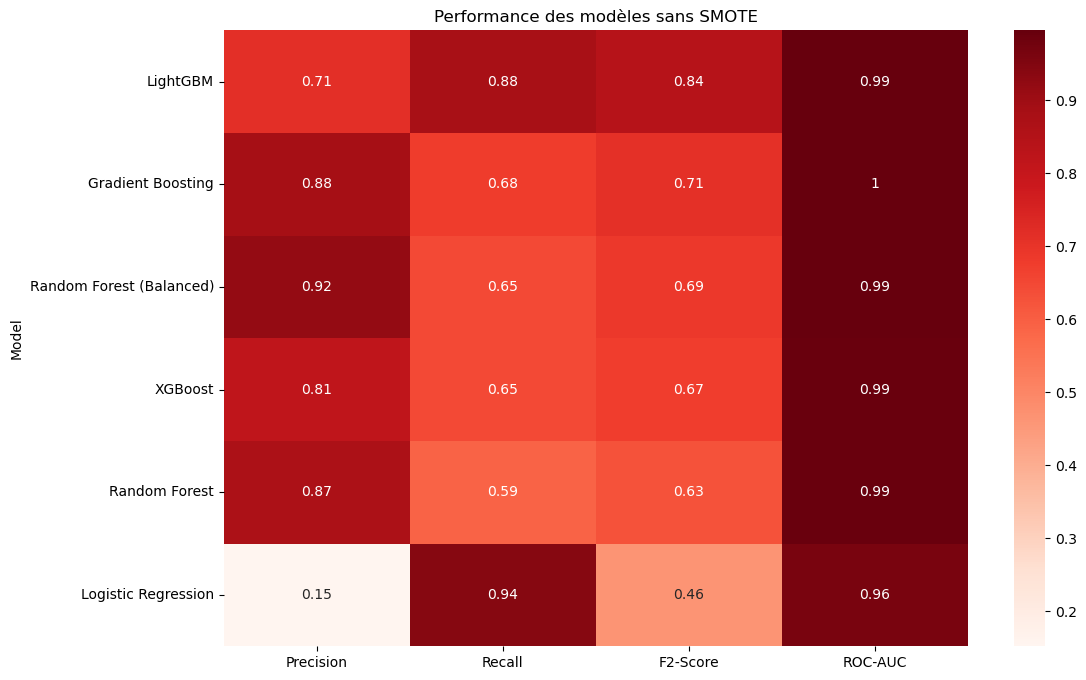

In [43]:
metrics_df_sorted = metrics_df.sort_values(by='F2-Score', ascending=False)
plt.figure(figsize=(12, 8))
sns.heatmap(metrics_df_sorted.set_index('Model').iloc[:, 1:], annot=True, cmap='Reds')
plt.title("Performance des modèles sans SMOTE")
plt.show()

Analyse des résultats sans l'application de SMOTE :
- LightGBM se démarque comme le modèle le plus performant grâce à un bon équilibre entre précision, rappel et F2-Score.
- Gradient Boosting est également robuste, mais légèrement en retrait sur le rappel.
- Les Random Forest (classique et équilibré) montrent des performances décentes mais des faiblesses en rappel.
- Logistic Regression n'est pas adapté à ce problème en raison de sa faible précision, malgré un rappel élevé.

Le LightGBM semble le plus adapter dans ce cas.

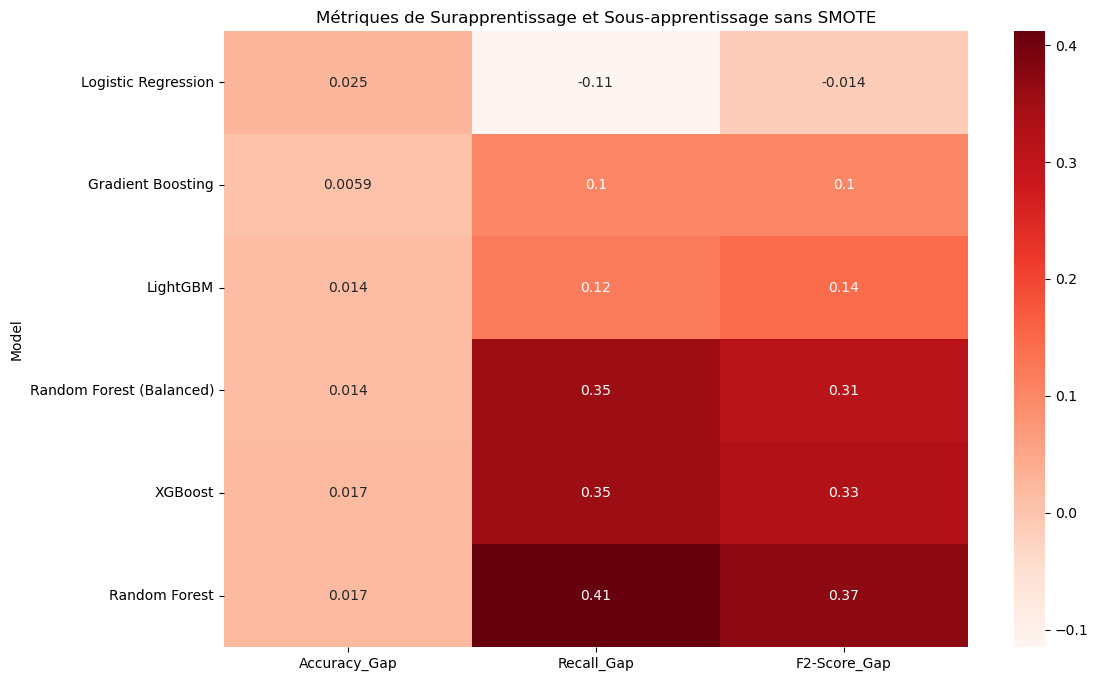

In [44]:
results_without_smote_df_gap_sorted = gaps_df.sort_values(by='F2-Score_Gap', ascending=True)
plt.figure(figsize=(12, 8))
sns.heatmap(results_without_smote_df_gap_sorted.set_index('Model').iloc[:, :], annot=True, cmap='Reds')
plt.title("Métriques de Surapprentissage et Sous-apprentissage sans SMOTE")
plt.show()

Les résultats montrent que Gradient Boosting et LightGBM sont les modèles les plus équilibrés et ils généralisent bien, avec des écarts minimes entre l'entraînement et le test. 

La cross-validation sert à évaluer la robustesse et la généralisation d’un modèle en le testant sur plusieurs sous-ensembles de données de tests et d'entrainement. Cela permet d'éviter une évaluation biaisée due à une partition unique des données et de détecter le surapprentissage.

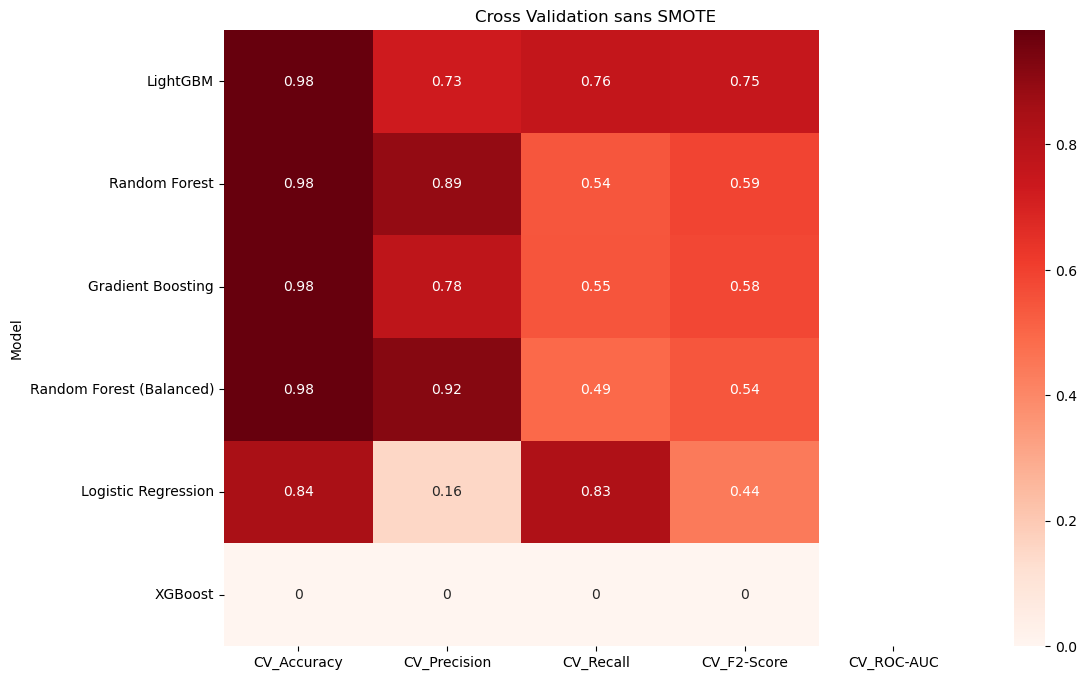

In [45]:
results_without_smote_df_cv_sorted = cv_results_df.replace('N/A', np.nan)
results_without_smote_df_cv_sorted = results_without_smote_df_cv_sorted.sort_values(by='CV_F2-Score', ascending=False)
plt.figure(figsize=(12, 8))
sns.heatmap(results_without_smote_df_cv_sorted.set_index('Model').iloc[:, :], annot=True, cmap='Reds')
plt.title("Cross Validation sans SMOTE")
plt.show()

LightGBM offre les meilleures performances globales 
Gradient Boosting peut être considéré comme une alternative solide.

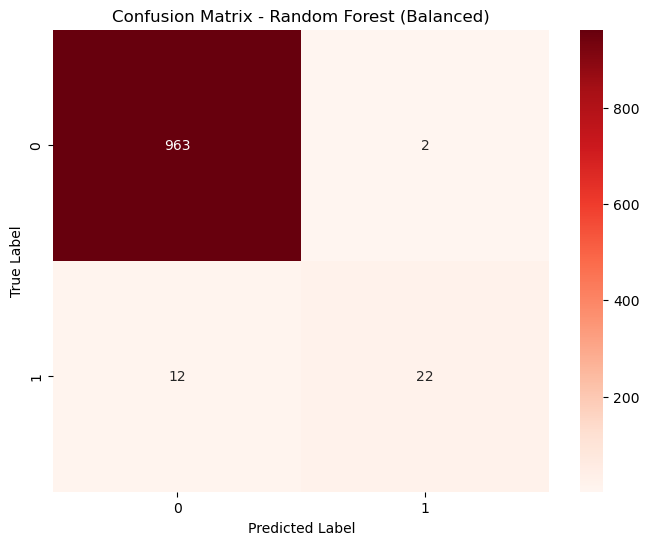

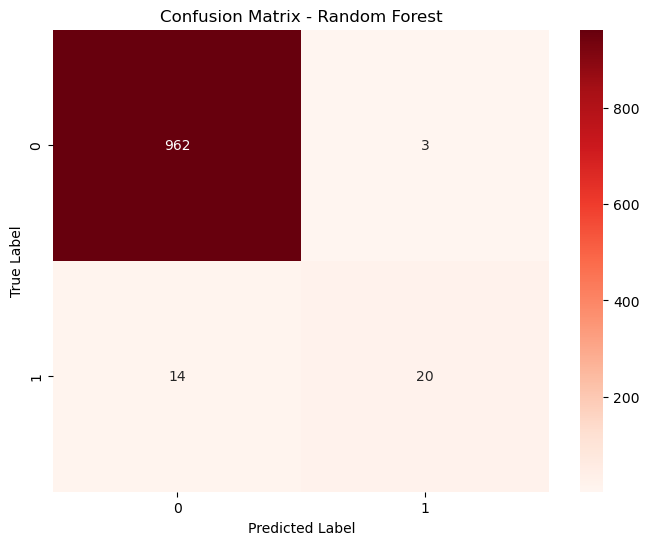

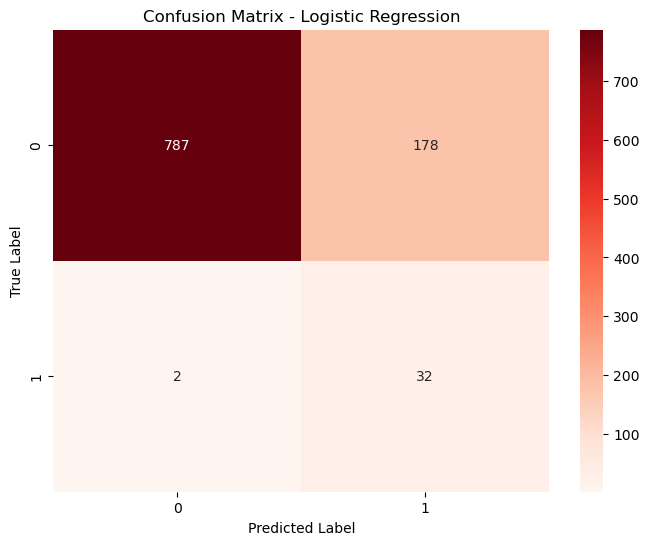

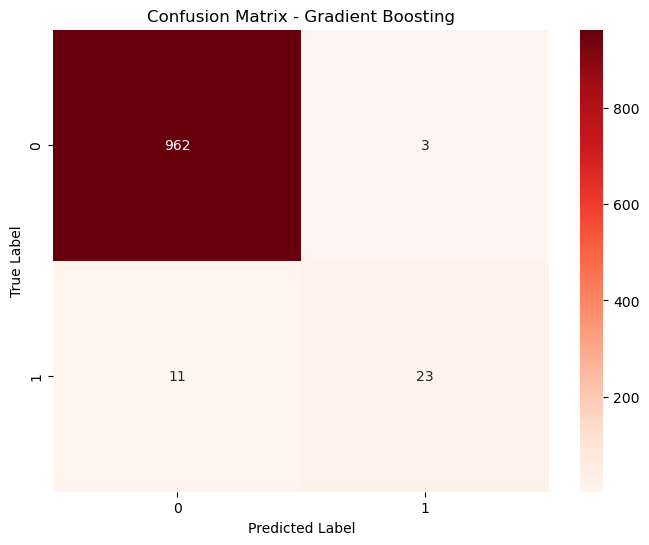

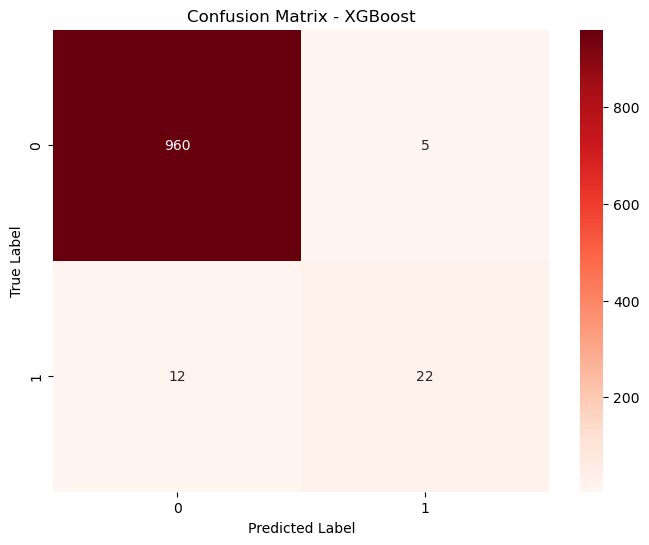

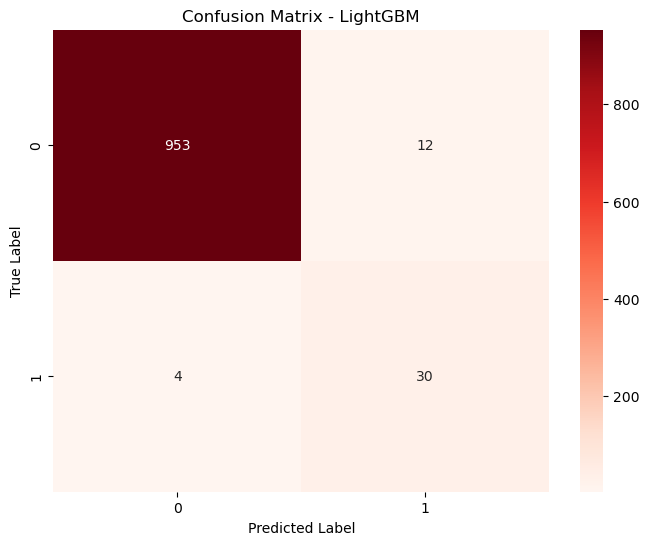

In [46]:
for name, conf_matrix in conf_matrices_without_smote.items():
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

En analysant les matrices de confusion pour chaque modèle, on peut conclure que, sans l'utilisation de SMOTE, LightGBM est le modèle le plus approprié. En effet, il ne manque que 4 pannes, bien qu'il génère un nombre notable de faux positifs. Gradient Boosting pourrait également être envisagé, mais il présente davantage de pannes non détectées, ce qui le rend moins performant pour les scénarios où le rappel (capture des pannes) est prioritaire.

### 6.4 Afficher les résultats avec SMOTE

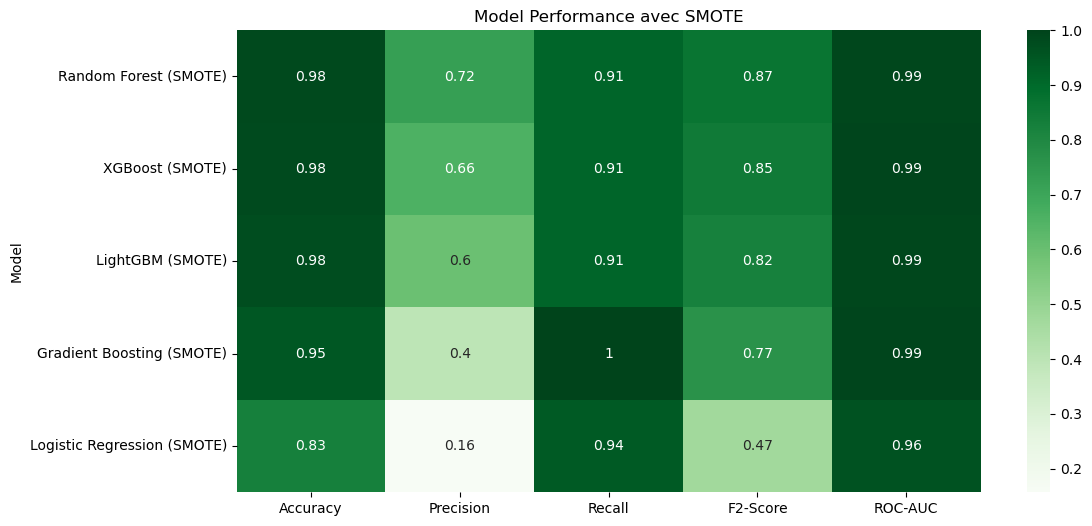

In [47]:
metrics_df_sorted_smote = metrics_df_with_smote.sort_values(by='F2-Score', ascending=False)
plt.figure(figsize=(12, 6))
sns.heatmap(metrics_df_sorted_smote.set_index('Model'), annot=True, cmap='Greens')
plt.title('Model Performance avec SMOTE')
plt.show()

Comparaison avec les résultats sans SMOTE :

- Sans SMOTE, les modèles comme LightGBM et Gradient Boosting montrent une bonne précision, mais un rappel plus faible (autour de 0.65-0.76), indiquant qu’ils passent à côté de nombreuses pannes.

- Avec SMOTE, le rappel s’améliore significativement (0.91 pour la majorité des modèles), montrant que les modèles identifient beaucoup mieux les pannes rares.

- Le principal compromis introduit par SMOTE est une légère augmentation des faux positifs, ce qui réduit la précision et le F2-Score pour certains modèles, comme Gradient Boosting.

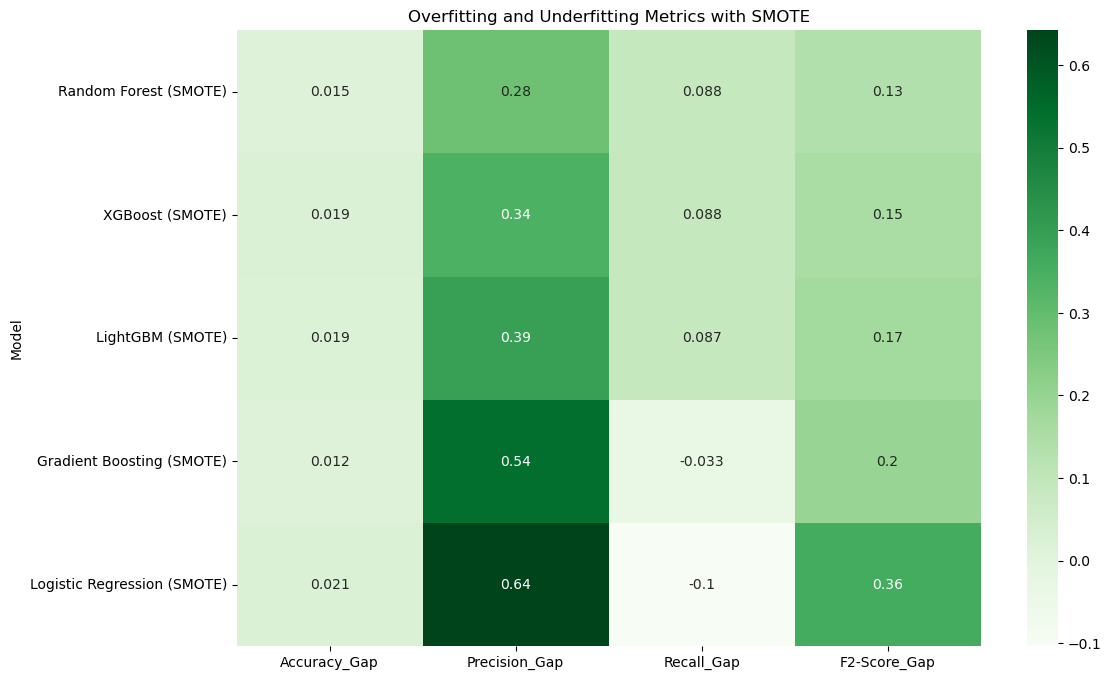

In [48]:
results_with_smote_df_gap_sorted = gaps_df_with_smote.sort_values(by='F2-Score_Gap', ascending=True)
plt.figure(figsize=(12, 8))
sns.heatmap(results_with_smote_df_gap_sorted.set_index('Model').iloc[:, :], annot=True, cmap='Greens')
plt.title("Overfitting and Underfitting Metrics with SMOTE")
plt.show()

- Gradient Boosting avec SMOTE détecte bien les pannes mais montre du surapprentissage car il a un écart de précision élevé.
- Random Forest (SMOTE) est le modèle le plus équilibré avec de bonnes performances globales.
- LightGBM et XGBoost (SMOTE) nécessiteraient un ajustement des hyperparamètres pour limiter le surapprentissage.
- Logistic Regression (SMOTE) est le moins adapté, souffrant d’un fort surapprentissage.

Random Forest (SMOTE) reste le modèle à privilégier pour sa capacité à bien généraliser, tout en restant équilibré dans la gestion du surapprentissage et sous-apprentissage.

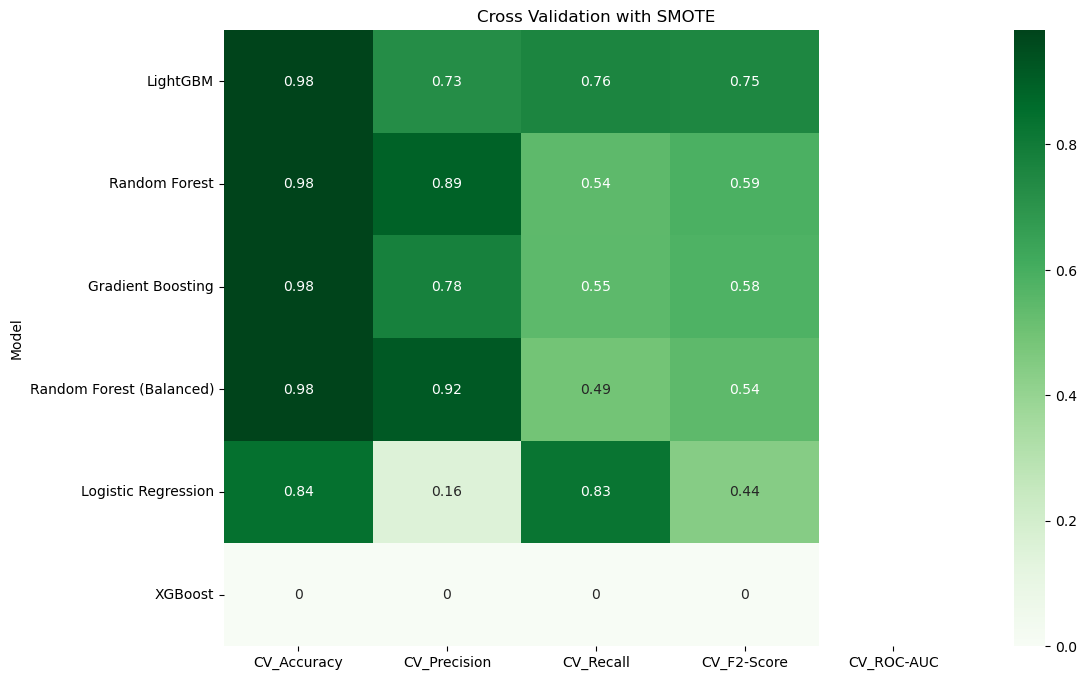

In [49]:
results_with_smote_df_cv_sorted = cv_results_df_with_smote.replace('N/A', np.nan)
results_with_smote_df_cv_sorted = results_with_smote_df_cv_sorted.sort_values(by='CV_F2-Score', ascending=False)
plt.figure(figsize=(12, 8))
sns.heatmap(results_without_smote_df_cv_sorted.set_index('Model').iloc[:, :], annot=True, cmap='Greens')
plt.title("Cross Validation with SMOTE")
plt.show()

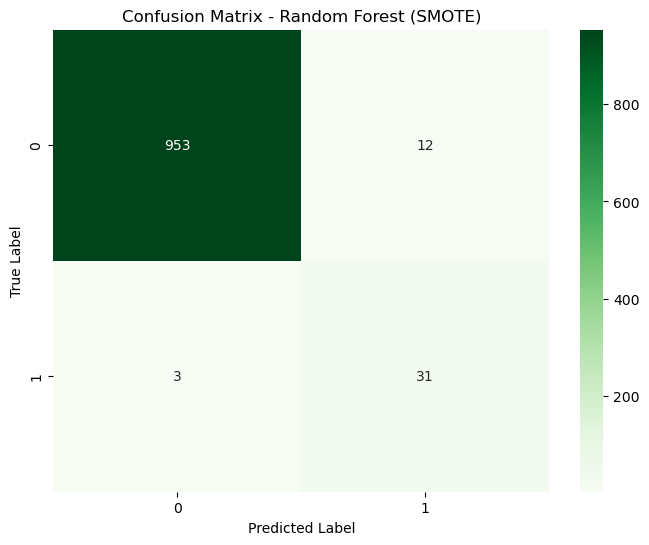

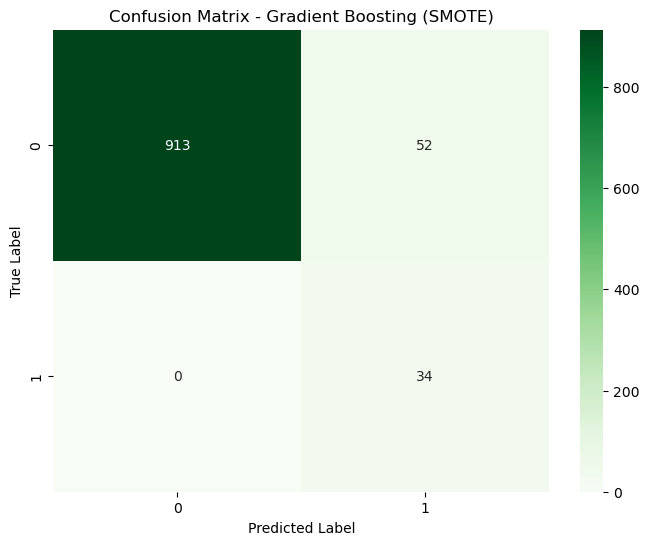

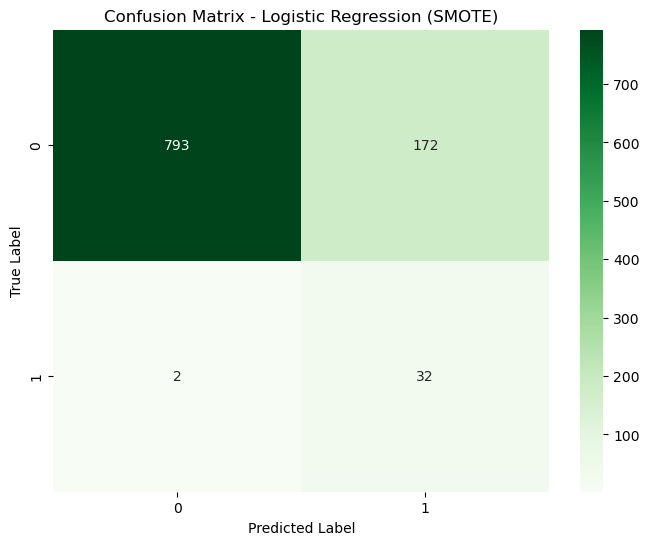

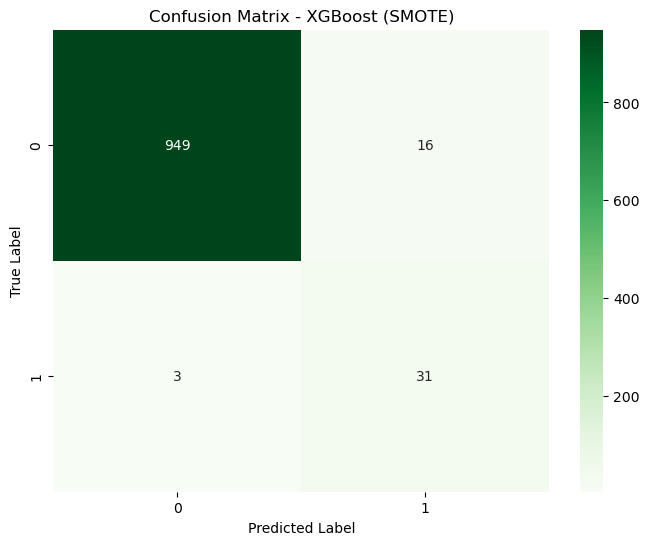

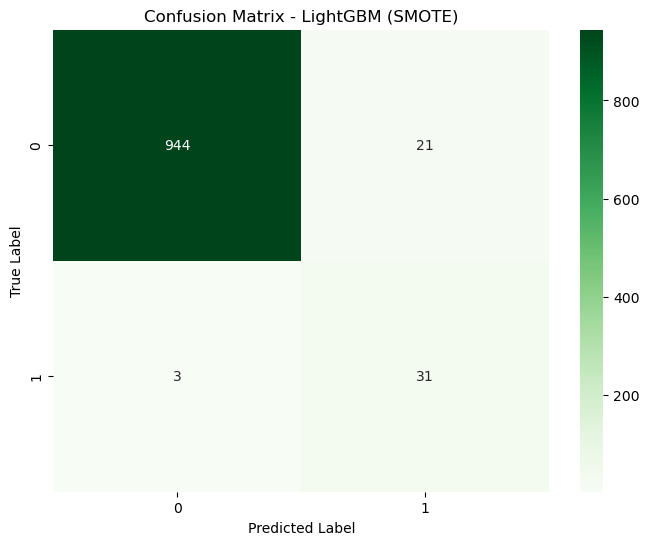

In [50]:
for name, conf_matrix in conf_matrices_with_smote.items():
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

XGBoost et Random Forest détectent efficacement de nombreuses pannes avec peu de faux positifs, confirmant leur solidité pour ce type de tâches. Cependant, ces modèles peuvent souffrir de surapprentissage si leurs hyperparamètres, comme la profondeur des arbres ou le taux d'apprentissage, ne sont pas bien réglés. LightGBM et Gradient Boosting offrent un meilleur équilibre entre précision et rappel, bien qu’ils génèrent plus de faux positifs. En conclusion, XGBoost et Random Forest sont performants mais nécessitent un réglage attentif pour éviter un surapprentissage et maintenir une bonne généralisation.

## 6.5 Conclusion :

Appliquer SMOTE a significativement amélioré la détection des pannes, ce qui est crucial pour un jeu de données déséquilibré. Les modèles avec SMOTE, comme Random Forest et XGBoost, montrent un équilibre solide entre précision et rappel, en minimisant les faux négatifs. Random Forest est le meilleur compromis. Cette approche justifie pleinement l’utilisation de SMOTE pour ce type de problème.

il est possible que les performances de XGBoost et Random Forest soient dues, en partie, à du surapprentissage. Cela pourrait expliquer leur capacité à détecter efficacement les pannes avec peu de faux positifs, car ils sont probablement très bien ajustés aux motifs spécifiques du jeu de données. Cependant, cela soulève une vulnérabilité potentielle : leur généralisation à des données nouvelles ou légèrement différentes pourrait être compromise.

Ainsi, même si ces modèles semblent performants, il est essentiel de valider leur robustesse sur des données externes et de continuer à ajuster leurs hyperparamètres pour limiter le surapprentissage. Un modèle légèrement moins performant mais mieux généralisé (comme LightGBM ou Gradient Boosting) pourrait, dans certains cas, offrir plus de garanties sur le long terme.

Pour limiter le surapprentissage observé chez XGBoost et Random Forest, des ajustements des hyperparamètres tels que la réduction de la profondeur des arbres, l'augmentation des échantillons minimums par feuille ou la diminution des taux d'apprentissage

In [51]:
""""
from sklearn.metrics import roc_curve
# Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

# Prédiction avec seuil ajusté
y_pred_adjusted = (y_proba >= optimal_threshold).astype(int)
"""

'"\nfrom sklearn.metrics import roc_curve\n# Courbe ROC\nfpr, tpr, thresholds = roc_curve(y_test, y_proba)\noptimal_idx = np.argmax(tpr - fpr)\noptimal_threshold = thresholds[optimal_idx]\n\n# Prédiction avec seuil ajusté\ny_pred_adjusted = (y_proba >= optimal_threshold).astype(int)\n'

In [52]:
""""
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer
from SklearnCompatibleXGBClassifier_Lib import SklearnCompatibleXGBClassifier

# Paramètres pour GridSearchCV
param_grid_xgb = {
   'n_estimators': [100, 300, 500],
    'max_depth': [5, 7],
    'learning_rate': [0.05, 0.1],
    'min_child_weight': [1, 5],
    'gamma': [0, 0.1],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [1, 3]
}

# Initialisation du modèle avec le wrapper
model = SklearnCompatibleXGBClassifier(eval_metric='logloss', random_state=42)

# Exécution de GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=model,
    param_grid=param_grid_xgb,
    scoring='f1',
    cv=5,
    verbose=2,
    n_jobs=-1
)

# Entraînement du modèle
grid_search_xgb.fit(X_train, y_train)

# Affichage des meilleurs paramètres
print("✅ Best Parameters for XGBoost:", grid_search_xgb.best_params_)
print("✅ Best F1-Score:", grid_search_xgb.best_score_)
"""

'"\nfrom sklearn.base import BaseEstimator, ClassifierMixin\nfrom sklearn.model_selection import GridSearchCV\nfrom sklearn.metrics import f1_score, make_scorer\nfrom SklearnCompatibleXGBClassifier_Lib import SklearnCompatibleXGBClassifier\n\n# Paramètres pour GridSearchCV\nparam_grid_xgb = {\n   \'n_estimators\': [100, 300, 500],\n    \'max_depth\': [5, 7],\n    \'learning_rate\': [0.05, 0.1],\n    \'min_child_weight\': [1, 5],\n    \'gamma\': [0, 0.1],\n    \'subsample\': [0.8, 0.9],\n    \'colsample_bytree\': [0.8, 1.0],\n    \'scale_pos_weight\': [1, 3]\n}\n\n# Initialisation du modèle avec le wrapper\nmodel = SklearnCompatibleXGBClassifier(eval_metric=\'logloss\', random_state=42)\n\n# Exécution de GridSearchCV\ngrid_search_xgb = GridSearchCV(\n    estimator=model,\n    param_grid=param_grid_xgb,\n    scoring=\'f1\',\n    cv=5,\n    verbose=2,\n    n_jobs=-1\n)\n\n# Entraînement du modèle\ngrid_search_xgb.fit(X_train, y_train)\n\n# Affichage des meilleurs paramètres\nprint("✅ Best

In [53]:
""""
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

# Define parameter grid
param_grid_gb = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 5],
    'subsample': [0.8, 0.9],
    'max_features': ['sqrt', 'log2']
}


# GridSearchCV
grid_search_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=param_grid_gb,
    scoring='f1',
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search_gb.fit(X_train, y_train)
print("✅ Best Parameters for Gradient Boosting:", grid_search_gb.best_params_)
print("✅ Best F1-Score:", grid_search_gb.best_score_)
"""

'"\nfrom sklearn.model_selection import GridSearchCV\nfrom sklearn.ensemble import GradientBoostingClassifier\n\n# Define parameter grid\nparam_grid_gb = {\n    \'n_estimators\': [100, 300, 500],\n    \'learning_rate\': [0.05, 0.1],\n    \'max_depth\': [3, 5, 7],\n    \'min_samples_split\': [2, 5],\n    \'min_samples_leaf\': [1, 5],\n    \'subsample\': [0.8, 0.9],\n    \'max_features\': [\'sqrt\', \'log2\']\n}\n\n\n# GridSearchCV\ngrid_search_gb = GridSearchCV(\n    GradientBoostingClassifier(random_state=42),\n    param_grid=param_grid_gb,\n    scoring=\'f1\',\n    cv=5,\n    verbose=2,\n    n_jobs=-1\n)\n\ngrid_search_gb.fit(X_train, y_train)\nprint("✅ Best Parameters for Gradient Boosting:", grid_search_gb.best_params_)\nprint("✅ Best F1-Score:", grid_search_gb.best_score_)\n'

In [54]:
models_with_smote_hp = {
    "Gradient Boosting (SMOTE)": GradientBoostingClassifier(random_state=42, learning_rate = 0.1, max_depth= 3, max_features= 'sqrt', min_samples_leaf= 5, min_samples_split= 2, n_estimators= 300, subsample= 0.8),
    "XGBoost (SMOTE)": XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1, colsample_bytree= 1.0, gamma= 0.1, learning_rate= 0.05, max_depth= 7, min_child_weight= 5, n_estimators= 100, scale_pos_weight= 3, subsample= 0.9),
}

In [55]:
""""
trained_models_with_smote_hp = {}

for name, model in models_with_smote_hp.items():
    smote = SMOTE(sampling_strategy=0.8, random_state=42, k_neighbors=3)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    model.fit(X_train_resampled, y_train_resampled)
    trained_models_with_smote_hp[name] = model

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else np.zeros_like(y_pred)
"""

'"\ntrained_models_with_smote_hp = {}\n\nfor name, model in models_with_smote_hp.items():\n    smote = SMOTE(sampling_strategy=0.8, random_state=42, k_neighbors=3)\n    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)\n    model.fit(X_train_resampled, y_train_resampled)\n    trained_models_with_smote_hp[name] = model\n\n    y_pred = model.predict(X_test)\n    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, \'predict_proba\') else np.zeros_like(y_pred)\n'

# 7.0 Modelisation de la détection du type de pannes

Nous allons maintenant entraîner des modèles pour détecter le type de panne, y compris la classe "No Failure", pour pouvoir fournir une classification précise des pannes de la machine. Comme pour la détection de panne, nous comparerons les performances avec et sans SMOTE pour identifier le modèle le plus performant. Cette fois, nous intégrerons des techniques d'amélioration des modèles pour optimiser les résultats.

## 7.1 Rééquilibrage des données avec SMOTE et Tomek Links

Ce code utilise SMOTE pour générer des échantillons synthétiques équilibrant les classes minoritaires, et Tomek Links pour éliminer les exemples ambiguës ou bruités. Le sampling_strategy="auto" ajuste automatiquement les classes minoritaires à la taille de la classe majoritaire, garantissant un équilibre optimal des données.

In [85]:
# Assurer que les labels sont sous forme entière
y_train_failure = y_train_failure_encoded.astype(int)
y_test_failure = y_test_failure_encoded.astype(int)
# SMOTE combiné à Tomek Links
smote_tomek = SMOTETomek(sampling_strategy="auto", random_state=42)
X_train_failure_resampled, y_train_failure_resampled = smote_tomek.fit_resample(X_train_pca_failure, y_train_failure)

print(pd.Series(y_train_failure_resampled).value_counts())

1    8686
0    8686
4    8686
3    8686
2    8686
Name: count, dtype: int64


Après application de SMOTE, toutes les classes sont parfaitement équilibrées avec 8686 échantillons chacune, ce qui élimine le déséquilibre initial tout en minimisant le bruit en générant des exemples synthétiques plutôt que de simplement dupliquer les données existantes.

## 7.2 Entraînement des modèles


### 7.2.1 Model mutli trained without SMOTE

Ce code prépare plusieurs modèles pour une classification multi-classes, comme Random Forest , Logistic Regression, Gradient Boosting, XGBoost et LightGBM. Les paramètres utilisés, comme class_weight='balanced' pour Random Forest, aident à mieux gérer les classes minoritaires. La régression logistique est configurée pour bien traiter plusieurs classes avec une pénalisation standard et un solveur adapté. La métrique mlogloss dans le XGBoost évalue la qualité des probabilités prédites par un modèle multi-classes, en pénalisant fortement les prédictions erronées et en favorisant des probabilités précises et bien calibrées.

Avec un petit dataset et des features peu équilibrées, un modèle trop robuste risque de sur-apprendre et de privilégier les classes dominantes, ce qui limite sa généralisation. C’est pourquoi on décide de ne pas trop toucher aux paramètres, afin de privilégier un modèle simple et régularisé pour des résultats plus fiables.

In [86]:
# Liste des modèles pour la classification multi-classes
models_multi = {
    "Random Forest (Balanced)": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42, multi_class='multinomial', solver='lbfgs', penalty='l2', C=1.0,  max_iter= 2000),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42)
}

Ce code entraîne plusieurs modèles de classification multi-classes sur les données d'entraînement, stocke les modèles entraînés, génère les prédictions et les probabilités associées pour chaque modèle.

In [87]:
trained_models_multi_without_smote = {}
predictions_multi_without_smote = {}
probabilities_multi_without_smote = {}

for name, model in models_multi.items():
    model.fit(X_train_pca_failure, y_train_failure)

    trained_models_multi_without_smote[name] = model
    
    y_pred_failure = model.predict(X_train_pca_failure)
    y_proba_failure = model.predict_proba(X_train_pca_failure) if hasattr(model, 'predict_proba') else None
    
    predictions_multi_without_smote[name] = y_pred_failure
    probabilities_multi_without_smote[name] = y_proba_failure

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000367 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 8983, number of used features: 7
[LightGBM] [Info] Start training from score -4.487969
[LightGBM] [Info] Start training from score -0.033621
[LightGBM] [Info] Start training from score -4.854594
[LightGBM] [Info] Start training from score -4.660438
[LightGBM] [Info] Start training from score -5.389517
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

Ces messages indiquent que LightGBM a terminé l'entraînement, mais certains arbres n'ont pas pu trouver de splits avec un gain positif, probablement en raison de limitations liées à des features non informatives ou des seuils atteints ou aux hyperparamètres

### 7.2.2 Model mutli trained without SMOTE

Ce code configure des modèles pour gérer des données rééquilibrées avec SMOTE. Les paramètres sont ajustés pour optimiser les performances : la Logistic Regression est réglée pour bien traiter les classes multiples, XGBoost utilise la métrique mlogloss pour le multi-classes, et LightGBM limite la profondeur des arbres (max_depth=5) pour éviter le surapprentissage. Ces réglages permettent aux modèles de mieux s’adapter aux données équilibrées sans trop se complexifier.

In [88]:
# Liste des modèles avec SMOTE pour la classification multi-classes
models_multi_smote = {
    "Random Forest (SMOTE)": RandomForestClassifier(random_state=42),
    "Logistic Regression (SMOTE)": LogisticRegression(max_iter=2000, random_state=42, multi_class='multinomial', solver='lbfgs'),
    "Gradient Boosting (SMOTE)": GradientBoostingClassifier(random_state=42),
    "XGBoost (SMOTE)": XGBClassifier(eval_metric='mlogloss', random_state=42),
    "LightGBM (SMOTE)": LGBMClassifier(random_state=42, max_depth=5)
}

Ce code entraîne différents modèles sur des données rééquilibrées avec SMOTE, puis les enregistre dans le dictionnaire trained_models_multi_with_smote pour pouvoir les réutiliser.

In [89]:
# Entraînement des modèles avec SMOTE
trained_models_multi_with_smote = {}

for name, model in models_multi_smote.items():

    model.fit(X_train_failure_resampled, y_train_failure_resampled)
    trained_models_multi_with_smote[name] = model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001392 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 43430, number of used features: 7
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

In [90]:
# Initialisation des structures de stockage
results_multi_without_smote = []
conf_matrices_multi_without_smote = {}

# Évaluation des modèles
for name, model in trained_models_multi_without_smote.items():
    
    # Prédictions sur les données de test
    y_pred_test = model.predict(X_test_pca_failure)
    y_proba_test = model.predict_proba(X_test_pca_failure) if hasattr(model, 'predict_proba') else None
    
    # Prédictions sur les données d'entraînement
    y_pred_train = model.predict(X_train_pca_failure)
    y_proba_train = model.predict_proba(X_train_pca_failure) if hasattr(model, 'predict_proba') else None
    
    # Calcul des métriques sur les données de test
    test_metrics = {
        "Accuracy": accuracy_score(y_test_failure_encoded, y_pred_test),
        "Precision": precision_score(y_test_failure_encoded, y_pred_test, average='weighted', zero_division=0),
        "Recall": recall_score(y_test_failure_encoded, y_pred_test, average='weighted', zero_division=0),
        "F2-Score": fbeta_score(y_test_failure_encoded, y_pred_test, beta=2, average='weighted', zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_failure_encoded, y_proba_test, multi_class='ovr') if y_proba_test is not None else 'N/A'
    }

    # Calcul des métriques sur les données d'entraînement
    train_metrics = {
        "Train_Accuracy": accuracy_score(y_train_failure_encoded, y_pred_train),
        "Train_Recall": recall_score(y_train_failure_encoded, y_pred_train, average='weighted', zero_division=0),
        "Train_F2-Score": fbeta_score(y_train_failure_encoded, y_pred_train, beta=2, average='weighted', zero_division=0)
    }
    
    # Calcul des écarts (GAP)
    metrics = {
        "Model": name,
        "Accuracy": test_metrics["Accuracy"],
        "Precision": test_metrics["Precision"],
        "Recall": test_metrics["Recall"],
        "F2-Score": test_metrics["F2-Score"],
        "ROC-AUC": test_metrics["ROC-AUC"],
        "Accuracy_Gap": train_metrics["Train_Accuracy"] - test_metrics["Accuracy"],
        "Recall_Gap": train_metrics["Train_Recall"] - test_metrics["Recall"],
        "F2-Score_Gap": train_metrics["Train_F2-Score"] - test_metrics["F2-Score"]
    }
    
    # Stockage des résultats et de la matrice de confusion
    results_multi_without_smote.append(metrics)
    conf_matrices_multi_without_smote[name] = confusion_matrix(y_test_failure_encoded, y_pred_test)

# Conversion des résultats en DataFrame
results_df = pd.DataFrame(results_multi_without_smote).sort_values(by='Recall', ascending=False)

In [91]:
# Initialisation des structures pour stocker les résultats
results_multi_with_smote = []
conf_matrices_multi_with_smote = {}

# Évaluation des modèles
for name, model in trained_models_multi_with_smote.items():
    
    # Prédictions sur les données de test
    y_pred_test_smote = model.predict(X_test_pca_failure)
    y_proba_test_smote = model.predict_proba(X_test_pca_failure) if hasattr(model, 'predict_proba') else None

    # Prédictions sur les données d'entraînement
    y_pred_train_smote = model.predict(X_train_failure_resampled)
    y_proba_train_smote = model.predict_proba(X_train_failure_resampled) if hasattr(model, 'predict_proba') else None
    
    # Calcul des métriques sur les données de test
    test_metrics_smote = {
        "Accuracy": accuracy_score(y_test_failure_encoded, y_pred_test_smote),
        "Precision": precision_score(y_test_failure_encoded, y_pred_test_smote, average='weighted', zero_division=0),
        "Recall": recall_score(y_test_failure_encoded, y_pred_test_smote, average='weighted', zero_division=0),
        "F2-Score": fbeta_score(y_test_failure_encoded, y_pred_test_smote, beta=2, average='weighted', zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_failure_encoded, y_proba_test_smote, multi_class='ovr') if y_proba_test_smote is not None else 'N/A'
    }

    # Calcul des métriques sur les données d'entraînement
    train_metrics_smote = {
        "Train_Accuracy": accuracy_score(y_train_failure_resampled, y_pred_train_smote),
        "Train_Recall": recall_score(y_train_failure_resampled, y_pred_train_smote, average='weighted', zero_division=0),
        "Train_F2-Score": fbeta_score(y_train_failure_resampled, y_pred_train_smote, beta=2, average='weighted', zero_division=0)
    }

    # Calcul des écarts (GAP)
    metrics_smote = {
        "Model": name,
        **test_metrics_smote,
        "Accuracy_Gap": train_metrics_smote["Train_Accuracy"] - test_metrics_smote["Accuracy"],
        "Recall_Gap": train_metrics_smote["Train_Recall"] - test_metrics_smote["Recall"],
        "F2-Score_Gap": train_metrics_smote["Train_F2-Score"] - test_metrics_smote["F2-Score"]
    }
    
    # Stockage des résultats
    results_multi_with_smote.append(metrics_smote)
    conf_matrices_multi_with_smote[name] = confusion_matrix(y_test_failure_encoded, y_pred_test_smote)

In [92]:
results_multi_without_smote_df = pd.DataFrame(results_multi_without_smote).sort_values(by='Recall', ascending=False)
print("Result without SMOTE :")
print(results_multi_without_smote_df)

Result without SMOTE :
                      Model  Accuracy  Precision    Recall  F2-Score  \
3         Gradient Boosting  0.983984   0.982374  0.983984  0.983430   
1             Random Forest  0.982983   0.978027  0.982983  0.981440   
5                  LightGBM  0.982983   0.980289  0.982983  0.982196   
0  Random Forest (Balanced)  0.979980   0.974907  0.979980  0.978214   
4                   XGBoost  0.979980   0.977677  0.979980  0.979407   
2       Logistic Regression  0.976977   0.971402  0.976977  0.975598   

    ROC-AUC  Accuracy_Gap  Recall_Gap  F2-Score_Gap  
3  0.980455      0.015905    0.015905      0.016458  
1  0.965053      0.017017    0.017017      0.018560  
5  0.993167      0.017017    0.017017      0.017804  
0  0.994878      0.020020    0.020020      0.021786  
4  0.993537      0.020020    0.020020      0.020593  
2  0.989808      0.003208    0.003208      0.002858  


In [93]:
results_multi_with_smote_df = pd.DataFrame(results_multi_with_smote).sort_values(by='Recall', ascending=False)
print("🔍 Result with SMOTE:")
print(results_multi_with_smote_df)

🔍 Result with SMOTE:
                         Model  Accuracy  Precision    Recall  F2-Score  \
0        Random Forest (SMOTE)  0.979980   0.984060  0.979980  0.980491   
3              XGBoost (SMOTE)  0.972973   0.983999  0.972973  0.974569   
4             LightGBM (SMOTE)  0.971972   0.984823  0.971972  0.973483   
2    Gradient Boosting (SMOTE)  0.956957   0.985081  0.956957  0.960468   
1  Logistic Regression (SMOTE)  0.892893   0.976987  0.892893  0.901926   

    ROC-AUC  Accuracy_Gap  Recall_Gap  F2-Score_Gap  
0  0.994424      0.020020    0.020020      0.019509  
3  0.991714      0.027027    0.027027      0.025431  
4  0.994106      0.026278    0.026278      0.024765  
2  0.990186      0.031761    0.031761      0.028192  
1  0.989456      0.063497    0.063497      0.054197  


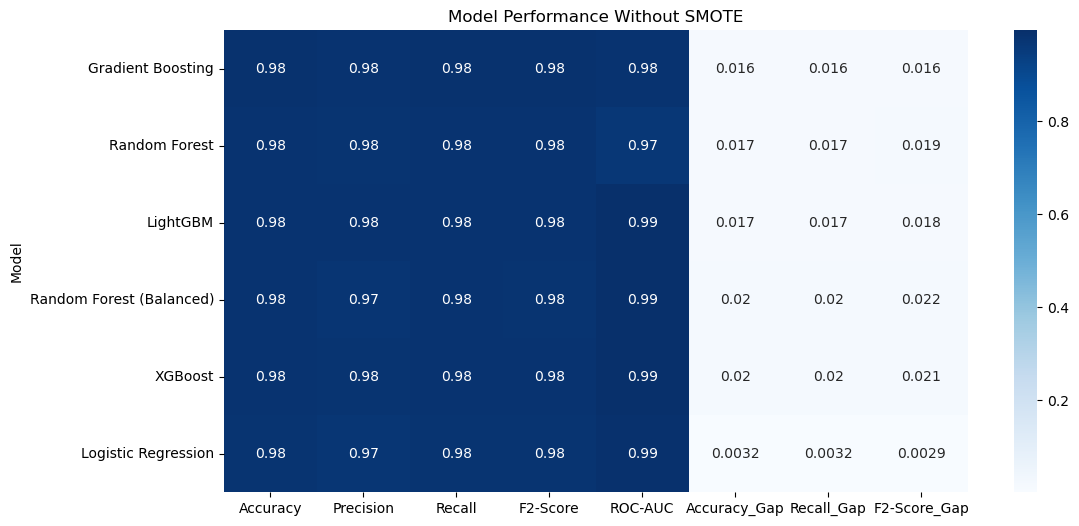

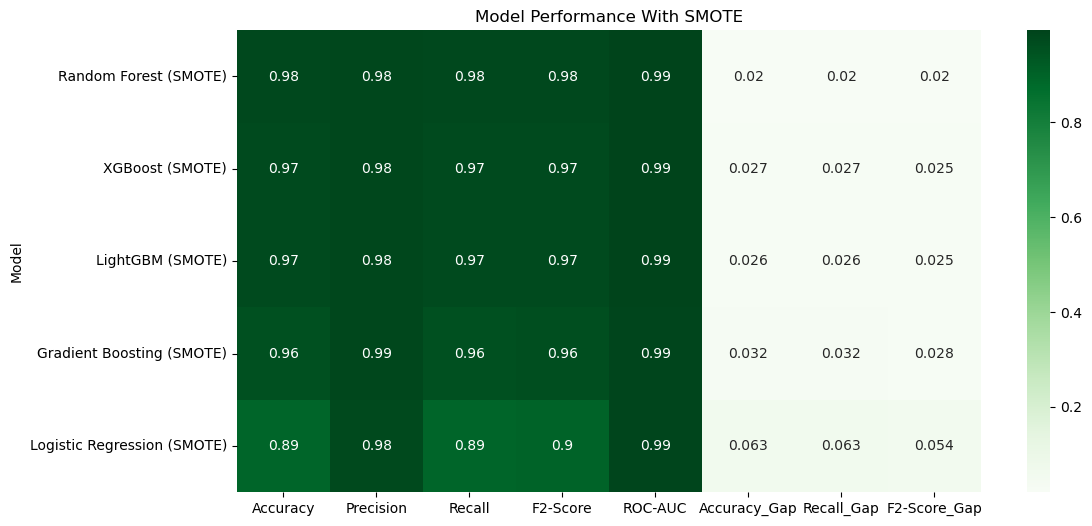

In [94]:
import seaborn as sns
import pandas as pd

# Créer des DataFrames pour les résultats
results_multi_without_smote_df = pd.DataFrame(results_multi_without_smote).sort_values(by='Recall', ascending=False)
results_multi_with_smote_df = pd.DataFrame(results_multi_with_smote).sort_values(by='Recall', ascending=False)

# Heatmap Without SMOTE
plt.figure(figsize=(12, 6))
sns.heatmap(results_multi_without_smote_df.set_index('Model'), annot=True, cmap='Blues')
plt.title('Model Performance Without SMOTE')
plt.show()

# Heatmap With SMOTE
plt.figure(figsize=(12, 6))
sns.heatmap(results_multi_with_smote_df.set_index('Model'), annot=True, cmap='Greens')
plt.title('Model Performance With SMOTE')
plt.show()


In [95]:
# Convertir en pandas Series pour accéder à .unique()
y_test_failure_series = pd.Series(y_test_failure)

# Afficher les labels uniques
print("y_test_failure unique labels:", y_test_failure_series.unique())



y_test_failure unique labels: [1 4 0 2 3]


📊 Génération de la matrice de confusion pour le modèle : Random Forest (Balanced)


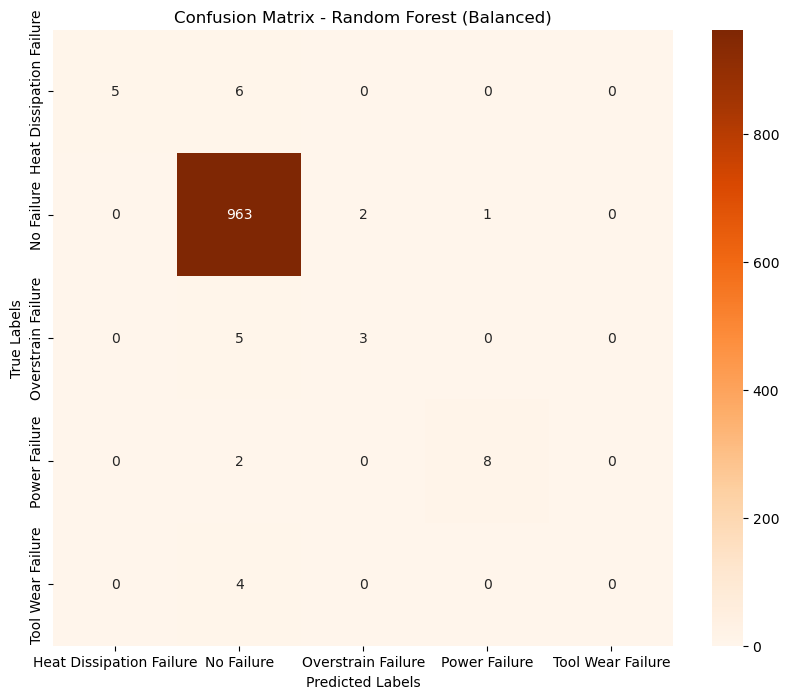


🔍 Rapport détaillé des prédictions (avec mapping des labels) :
                          Heat Dissipation Failure  No Failure  \
Heat Dissipation Failure                         5           6   
No Failure                                       0         963   
Overstrain Failure                               0           5   
Power Failure                                    0           2   
Tool Wear Failure                                0           4   

                          Overstrain Failure  Power Failure  Tool Wear Failure  
Heat Dissipation Failure                   0              0                  0  
No Failure                                 2              1                  0  
Overstrain Failure                         3              0                  0  
Power Failure                              0              8                  0  
Tool Wear Failure                          0              0                  0  
📊 Génération de la matrice de confusion pour le modèl

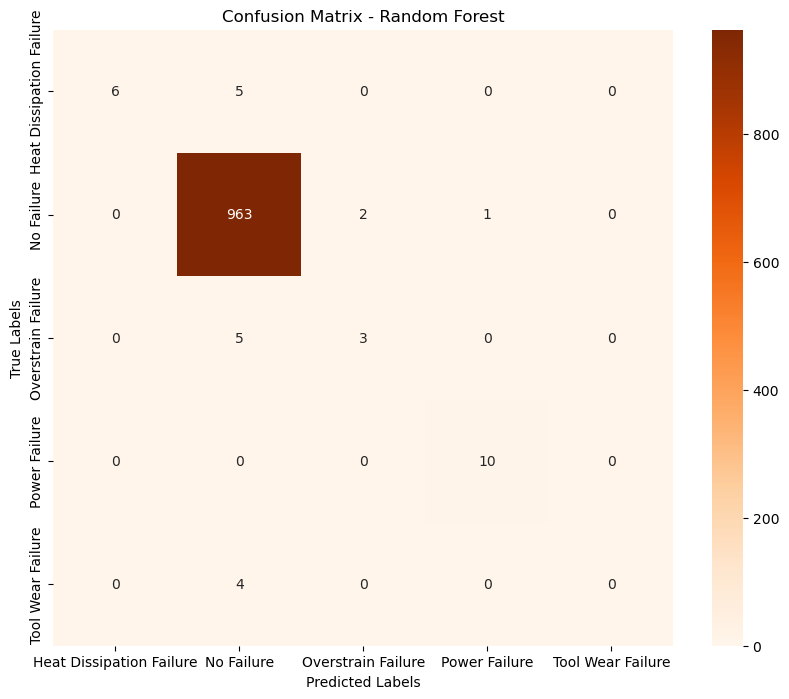


🔍 Rapport détaillé des prédictions (avec mapping des labels) :
                          Heat Dissipation Failure  No Failure  \
Heat Dissipation Failure                         6           5   
No Failure                                       0         963   
Overstrain Failure                               0           5   
Power Failure                                    0           0   
Tool Wear Failure                                0           4   

                          Overstrain Failure  Power Failure  Tool Wear Failure  
Heat Dissipation Failure                   0              0                  0  
No Failure                                 2              1                  0  
Overstrain Failure                         3              0                  0  
Power Failure                              0             10                  0  
Tool Wear Failure                          0              0                  0  
📊 Génération de la matrice de confusion pour le modèl

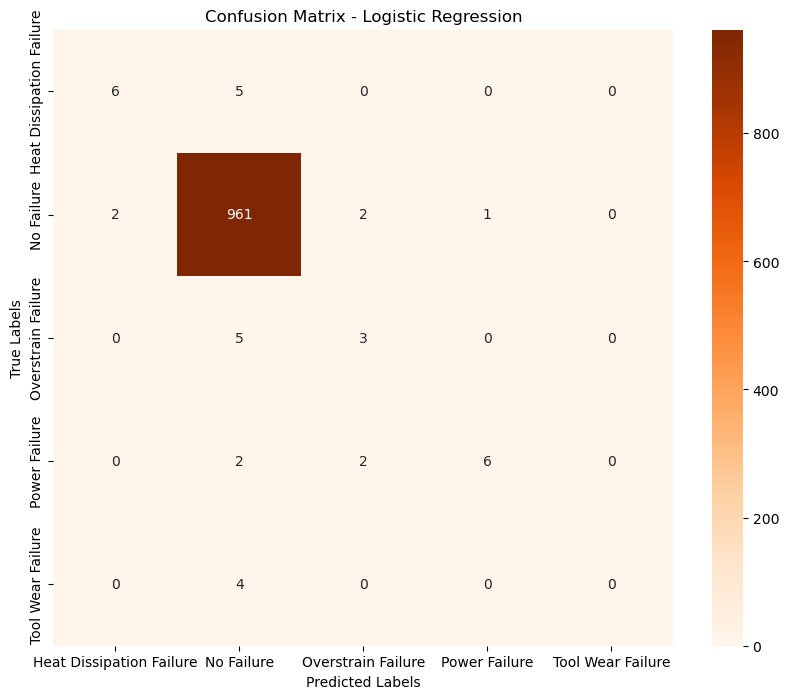


🔍 Rapport détaillé des prédictions (avec mapping des labels) :
                          Heat Dissipation Failure  No Failure  \
Heat Dissipation Failure                         6           5   
No Failure                                       2         961   
Overstrain Failure                               0           5   
Power Failure                                    0           2   
Tool Wear Failure                                0           4   

                          Overstrain Failure  Power Failure  Tool Wear Failure  
Heat Dissipation Failure                   0              0                  0  
No Failure                                 2              1                  0  
Overstrain Failure                         3              0                  0  
Power Failure                              2              6                  0  
Tool Wear Failure                          0              0                  0  
📊 Génération de la matrice de confusion pour le modèl

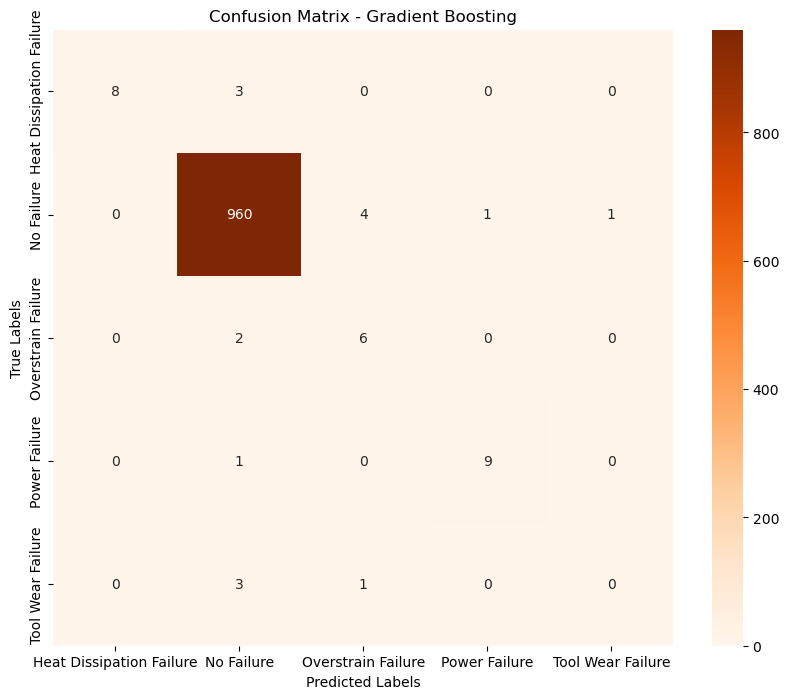


🔍 Rapport détaillé des prédictions (avec mapping des labels) :
                          Heat Dissipation Failure  No Failure  \
Heat Dissipation Failure                         8           3   
No Failure                                       0         960   
Overstrain Failure                               0           2   
Power Failure                                    0           1   
Tool Wear Failure                                0           3   

                          Overstrain Failure  Power Failure  Tool Wear Failure  
Heat Dissipation Failure                   0              0                  0  
No Failure                                 4              1                  1  
Overstrain Failure                         6              0                  0  
Power Failure                              0              9                  0  
Tool Wear Failure                          1              0                  0  
📊 Génération de la matrice de confusion pour le modèl

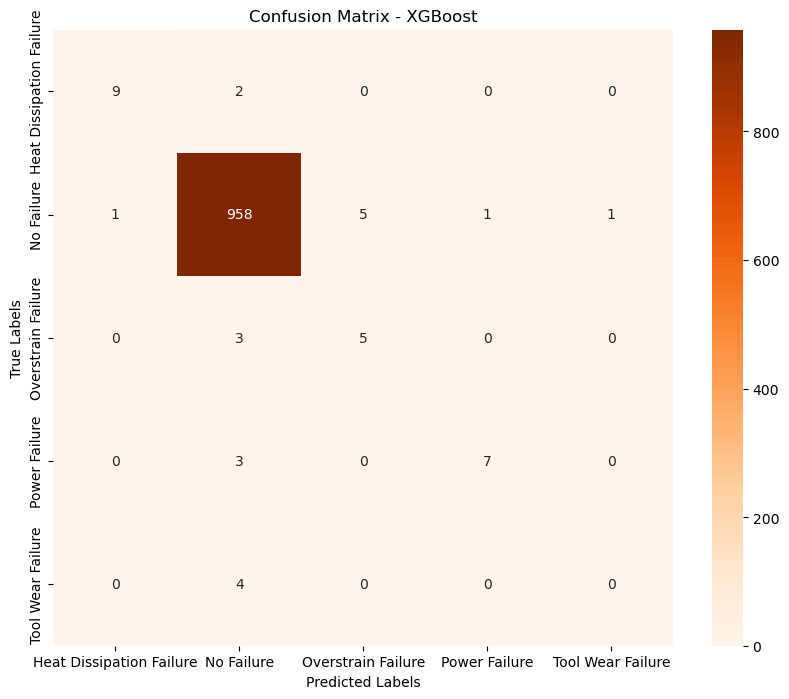


🔍 Rapport détaillé des prédictions (avec mapping des labels) :
                          Heat Dissipation Failure  No Failure  \
Heat Dissipation Failure                         9           2   
No Failure                                       1         958   
Overstrain Failure                               0           3   
Power Failure                                    0           3   
Tool Wear Failure                                0           4   

                          Overstrain Failure  Power Failure  Tool Wear Failure  
Heat Dissipation Failure                   0              0                  0  
No Failure                                 5              1                  1  
Overstrain Failure                         5              0                  0  
Power Failure                              0              7                  0  
Tool Wear Failure                          0              0                  0  
📊 Génération de la matrice de confusion pour le modèl

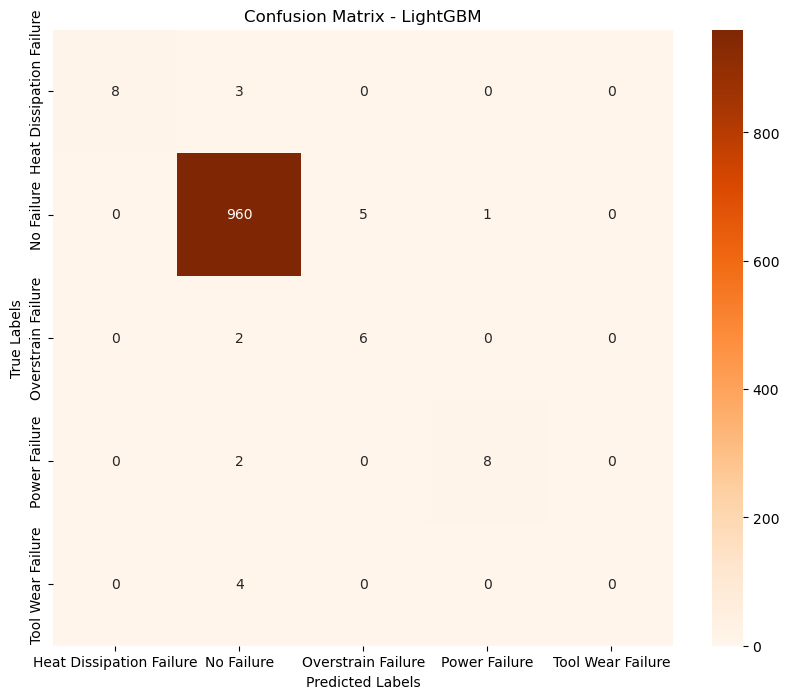


🔍 Rapport détaillé des prédictions (avec mapping des labels) :
                          Heat Dissipation Failure  No Failure  \
Heat Dissipation Failure                         8           3   
No Failure                                       0         960   
Overstrain Failure                               0           2   
Power Failure                                    0           2   
Tool Wear Failure                                0           4   

                          Overstrain Failure  Power Failure  Tool Wear Failure  
Heat Dissipation Failure                   0              0                  0  
No Failure                                 5              1                  0  
Overstrain Failure                         6              0                  0  
Power Failure                              0              8                  0  
Tool Wear Failure                          0              0                  0  


In [96]:

import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

# Mapping des labels encodés
label_mapping = {
    0: 'Heat Dissipation Failure',
    1: 'No Failure',
    2: 'Overstrain Failure',
    3: 'Power Failure',
    4: 'Tool Wear Failure'
}

# Création des listes pour les axes de la heatmap
xticklabels = [label_mapping[i] for i in range(len(label_mapping))]
yticklabels = [label_mapping[i] for i in range(len(label_mapping))]

# Boucle pour afficher une matrice de confusion pour chaque modèle
for name, model in trained_models_multi_without_smote.items():
    print(f"📊 Génération de la matrice de confusion pour le modèle : {name}")
    
    # Prédictions
    y_pred_multi = model.predict(X_test_pca_failure)
    
    # Calcul de la matrice de confusion
    conf_matrix = confusion_matrix(y_test_failure, y_pred_multi, labels=range(len(label_mapping)))
    
    # Affichage sous forme de heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        conf_matrix,
        annot=True,        # Affiche les valeurs numériques dans chaque cellule
        fmt='d',           # Format entier pour les valeurs
        cmap='Oranges',    # Couleurs oranges pour différencier du SMOTE
        xticklabels=xticklabels,  # Étiquettes des colonnes avec le mapping
        yticklabels=yticklabels   # Étiquettes des lignes avec le mapping
    )
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()
    
    # Afficher les résultats sous forme de tableau lisible
    conf_matrix_df = pd.DataFrame(conf_matrix, index=yticklabels, columns=xticklabels)
    print("\n🔍 Rapport détaillé des prédictions (avec mapping des labels) :")
    print(conf_matrix_df)


📊 Génération de la matrice de confusion pour le modèle : Random Forest (SMOTE)


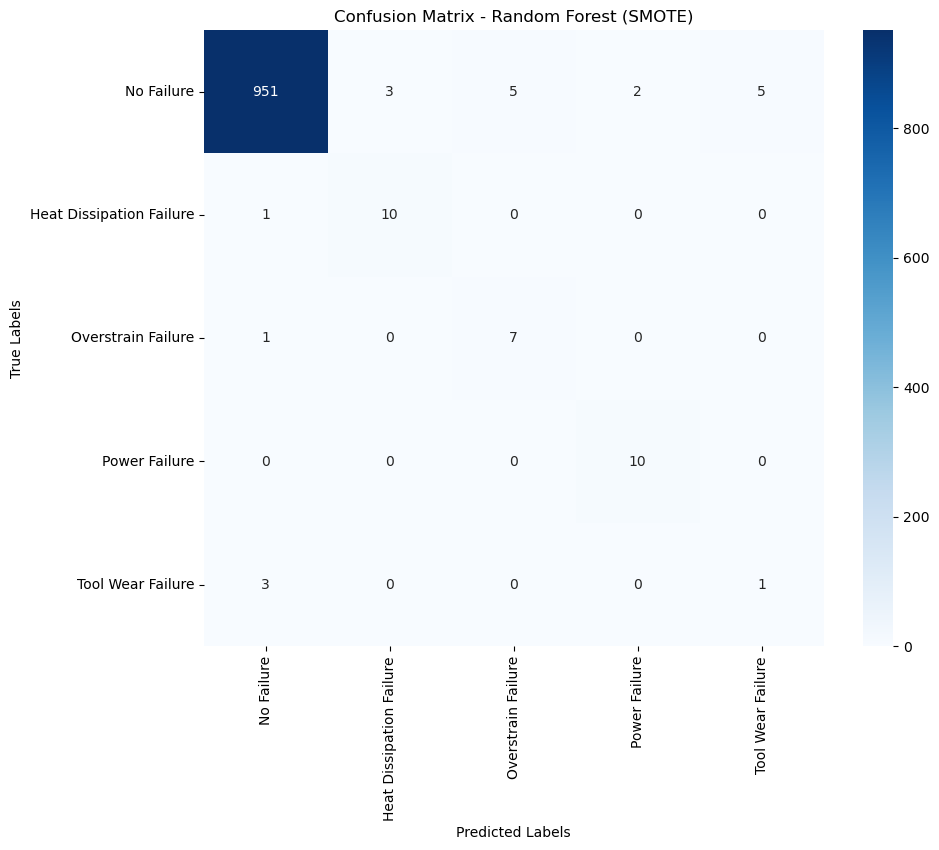


🔍 Rapport détaillé des prédictions :
                          No Failure  Heat Dissipation Failure  \
No Failure                       951                         3   
Heat Dissipation Failure           1                        10   
Overstrain Failure                 1                         0   
Power Failure                      0                         0   
Tool Wear Failure                  3                         0   

                          Overstrain Failure  Power Failure  Tool Wear Failure  
No Failure                                 5              2                  5  
Heat Dissipation Failure                   0              0                  0  
Overstrain Failure                         7              0                  0  
Power Failure                              0             10                  0  
Tool Wear Failure                          0              0                  1  
📊 Génération de la matrice de confusion pour le modèle : Logistic Regression (S

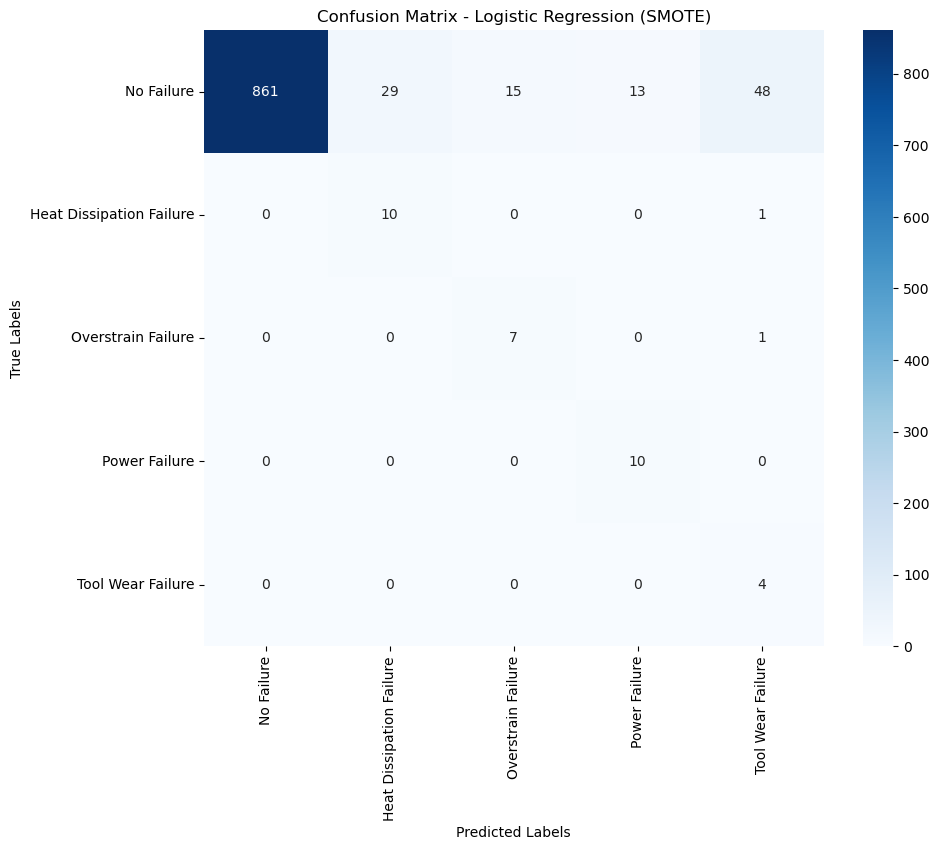


🔍 Rapport détaillé des prédictions :
                          No Failure  Heat Dissipation Failure  \
No Failure                       861                        29   
Heat Dissipation Failure           0                        10   
Overstrain Failure                 0                         0   
Power Failure                      0                         0   
Tool Wear Failure                  0                         0   

                          Overstrain Failure  Power Failure  Tool Wear Failure  
No Failure                                15             13                 48  
Heat Dissipation Failure                   0              0                  1  
Overstrain Failure                         7              0                  1  
Power Failure                              0             10                  0  
Tool Wear Failure                          0              0                  4  
📊 Génération de la matrice de confusion pour le modèle : Gradient Boosting (SMO

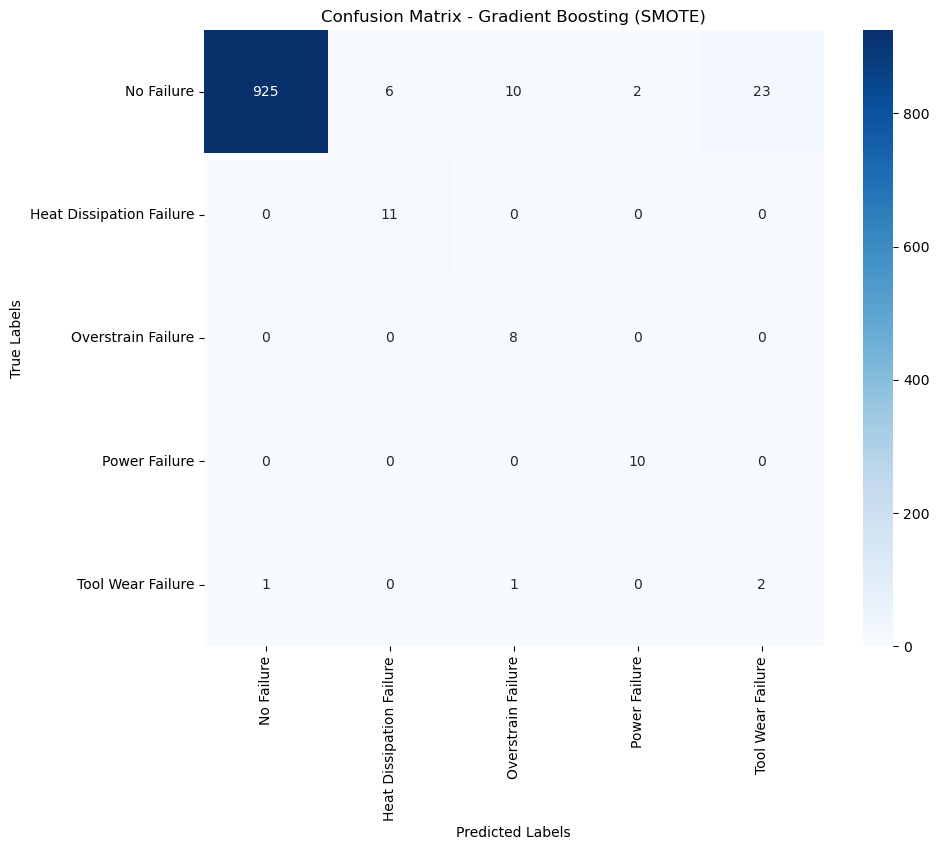


🔍 Rapport détaillé des prédictions :
                          No Failure  Heat Dissipation Failure  \
No Failure                       925                         6   
Heat Dissipation Failure           0                        11   
Overstrain Failure                 0                         0   
Power Failure                      0                         0   
Tool Wear Failure                  1                         0   

                          Overstrain Failure  Power Failure  Tool Wear Failure  
No Failure                                10              2                 23  
Heat Dissipation Failure                   0              0                  0  
Overstrain Failure                         8              0                  0  
Power Failure                              0             10                  0  
Tool Wear Failure                          1              0                  2  
📊 Génération de la matrice de confusion pour le modèle : XGBoost (SMOTE)


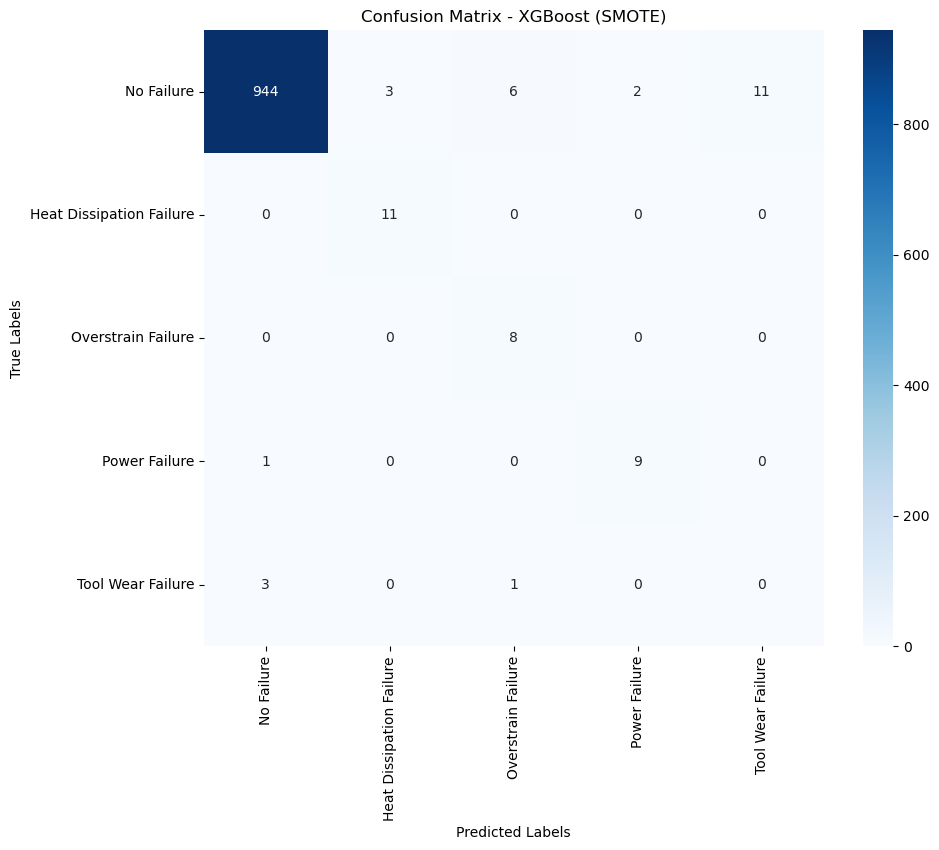


🔍 Rapport détaillé des prédictions :
                          No Failure  Heat Dissipation Failure  \
No Failure                       944                         3   
Heat Dissipation Failure           0                        11   
Overstrain Failure                 0                         0   
Power Failure                      1                         0   
Tool Wear Failure                  3                         0   

                          Overstrain Failure  Power Failure  Tool Wear Failure  
No Failure                                 6              2                 11  
Heat Dissipation Failure                   0              0                  0  
Overstrain Failure                         8              0                  0  
Power Failure                              0              9                  0  
Tool Wear Failure                          1              0                  0  
📊 Génération de la matrice de confusion pour le modèle : LightGBM (SMOTE)


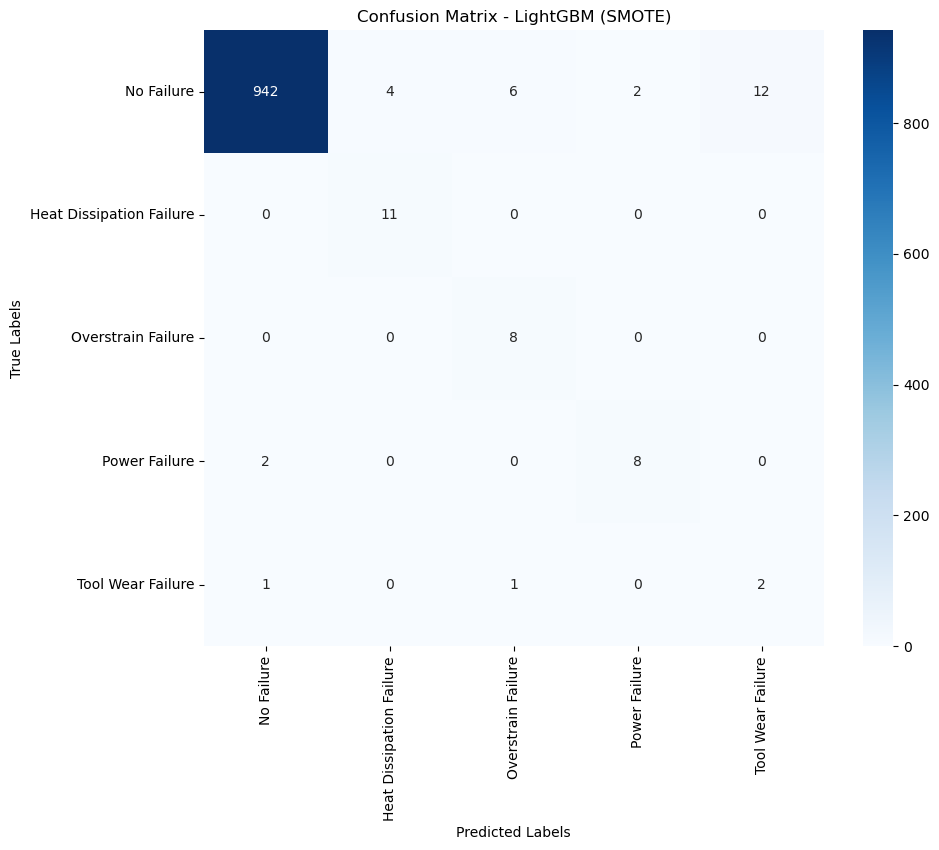


🔍 Rapport détaillé des prédictions :
                          No Failure  Heat Dissipation Failure  \
No Failure                       942                         4   
Heat Dissipation Failure           0                        11   
Overstrain Failure                 0                         0   
Power Failure                      2                         0   
Tool Wear Failure                  1                         0   

                          Overstrain Failure  Power Failure  Tool Wear Failure  
No Failure                                 6              2                 12  
Heat Dissipation Failure                   0              0                  0  
Overstrain Failure                         8              0                  0  
Power Failure                              0              8                  0  
Tool Wear Failure                          1              0                  2  


In [97]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Mapping des labels encodés
class_names = ['No Failure', 'Heat Dissipation Failure', 'Overstrain Failure', 'Power Failure', 'Tool Wear Failure']

# Boucle pour afficher une matrice de confusion pour chaque modèle
for name, model in trained_models_multi_with_smote.items():
    print(f"📊 Génération de la matrice de confusion pour le modèle : {name}")
    
    # Prédictions
    y_pred_multi = model.predict(X_test_pca_failure)
    
    # Calcul de la matrice de confusion
    conf_matrix = confusion_matrix(y_test_failure, y_pred_multi, labels=[1, 0, 2, 3, 4])
    
    # Affichage sous forme de heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()
    
    # Afficher les résultats en tableau lisible
    conf_matrix_df = pd.DataFrame(conf_matrix, index=class_names, columns=class_names)
    print("\n🔍 Rapport détaillé des prédictions :")
    print(conf_matrix_df)


In [98]:
""""
from sklearn.metrics import classification_report

print(y_test.unique())
print(len(y_test.unique()))


# Évaluation détaillée du modèle
print(classification_report(y_test_multi, y_pred_multi, target_names=['No Failure', 'Power Failure', 'Tool Wear Failure','Overstrain Failure','Heat Dissipation Failure']))
"""

'"\nfrom sklearn.metrics import classification_report\n\nprint(y_test.unique())\nprint(len(y_test.unique()))\n\n\n# Évaluation détaillée du modèle\nprint(classification_report(y_test_multi, y_pred_multi, target_names=[\'No Failure\', \'Power Failure\', \'Tool Wear Failure\',\'Overstrain Failure\',\'Heat Dissipation Failure\']))\n'

In [99]:
""""
import numpy as np

from sklearn.preprocessing import OneHotEncoder

# Fonction Softmax
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Fonction de coût pour la régression logistique multiclasse
def compute_cost_multiclass(X, Y, theta):
    m = X.shape[0]
    z = np.dot(X, theta)
    h = softmax(z)
    cost = -1/m * np.sum(Y * np.log(h + 1e-9))  # Petit epsilon pour éviter log(0)
    return cost

# Descente de gradient multiclasse
def gradient_descent_multiclass(X, Y, theta, alpha, num_iters):
    m = X.shape[0]
    cost_history = []
    
    for i in range(num_iters):
        z = np.dot(X, theta)
        h = softmax(z)
        gradient = (1/m) * np.dot(X.T, (h - Y))
        theta -= alpha * gradient
        cost = compute_cost_multiclass(X, Y, theta)
        cost_history.append(cost)
        
        if i % 100 == 0:
            print(f"Iteration {i}: Cost = {cost:.4f}")
    
    return theta, cost_history
"""

'"\nimport numpy as np\n\nfrom sklearn.preprocessing import OneHotEncoder\n\n# Fonction Softmax\ndef softmax(z):\n    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))\n    return exp_z / np.sum(exp_z, axis=1, keepdims=True)\n\n# Fonction de coût pour la régression logistique multiclasse\ndef compute_cost_multiclass(X, Y, theta):\n    m = X.shape[0]\n    z = np.dot(X, theta)\n    h = softmax(z)\n    cost = -1/m * np.sum(Y * np.log(h + 1e-9))  # Petit epsilon pour éviter log(0)\n    return cost\n\n# Descente de gradient multiclasse\ndef gradient_descent_multiclass(X, Y, theta, alpha, num_iters):\n    m = X.shape[0]\n    cost_history = []\n    \n    for i in range(num_iters):\n        z = np.dot(X, theta)\n        h = softmax(z)\n        gradient = (1/m) * np.dot(X.T, (h - Y))\n        theta -= alpha * gradient\n        cost = compute_cost_multiclass(X, Y, theta)\n        cost_history.append(cost)\n        \n        if i % 100 == 0:\n            print(f"Iteration {i}: Cost = {cost:.4f

In [100]:
""""
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Encodage One-Hot de y_train et y_test
encoder = OneHotEncoder(sparse_output=False)
y_train_encoded = encoder.fit_transform(y_train_multi.to_numpy().reshape(-1, 1))
y_test_encoded = encoder.transform(y_test_multi.to_numpy().reshape(-1, 1))

# Ajout d'un biais à X_train et X_test
X_train_bias = np.c_[np.ones((X_train.shape[0], 1)), X_train_multi]
X_test_bias = np.c_[np.ones((X_test.shape[0], 1)), X_test_multi]

# Initialisation des paramètres
np.random.seed(42)
num_classes = y_train_encoded.shape[1]
num_features = X_train_bias.shape[1]
theta = np.random.rand(num_features, num_classes) * 0.01
"""

'"\nfrom sklearn.preprocessing import OneHotEncoder\nimport numpy as np\n\n# Encodage One-Hot de y_train et y_test\nencoder = OneHotEncoder(sparse_output=False)\ny_train_encoded = encoder.fit_transform(y_train_multi.to_numpy().reshape(-1, 1))\ny_test_encoded = encoder.transform(y_test_multi.to_numpy().reshape(-1, 1))\n\n# Ajout d\'un biais à X_train et X_test\nX_train_bias = np.c_[np.ones((X_train.shape[0], 1)), X_train_multi]\nX_test_bias = np.c_[np.ones((X_test.shape[0], 1)), X_test_multi]\n\n# Initialisation des paramètres\nnp.random.seed(42)\nnum_classes = y_train_encoded.shape[1]\nnum_features = X_train_bias.shape[1]\ntheta = np.random.rand(num_features, num_classes) * 0.01\n'

In [101]:
""""
# Paramètres d'entraînement
learning_rate = 0.01
iterations = 1000

# Entraînement du modèle
optimal_theta, cost_history = gradient_descent_multiclass(X_train_bias, y_train_encoded, theta, learning_rate, iterations)
"""


'"\n# Paramètres d\'entraînement\nlearning_rate = 0.01\niterations = 1000\n\n# Entraînement du modèle\noptimal_theta, cost_history = gradient_descent_multiclass(X_train_bias, y_train_encoded, theta, learning_rate, iterations)\n'

In [102]:
""""
# Affichage de l'évolution du coût
plt.figure(figsize=(10, 6))
plt.plot(range(len(cost_history)), cost_history, label='Cost')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost Function over Iterations (Multiclass Logistic Regression)')
plt.legend()
plt.show()
"""

'"\n# Affichage de l\'évolution du coût\nplt.figure(figsize=(10, 6))\nplt.plot(range(len(cost_history)), cost_history, label=\'Cost\')\nplt.xlabel(\'Iterations\')\nplt.ylabel(\'Cost\')\nplt.title(\'Cost Function over Iterations (Multiclass Logistic Regression)\')\nplt.legend()\nplt.show()\n'

In [103]:
""""
# Prédictions avec le modèle entraîné
z_test = np.dot(X_test_bias, optimal_theta)
y_pred_proba = softmax(z_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_test_labels = np.argmax(y_test_encoded, axis=1)
"""

'"\n# Prédictions avec le modèle entraîné\nz_test = np.dot(X_test_bias, optimal_theta)\ny_pred_proba = softmax(z_test)\ny_pred = np.argmax(y_pred_proba, axis=1)\ny_test_labels = np.argmax(y_test_encoded, axis=1)\n'